# Refine myeloid-cell states in the AL bone marrow

**Biology rationale.** Myeloid populations are major receivers and mediators of inflammatory and immunoregulatory plasma-cell signaling.

**Aim.** Subset, integrate, and annotate myeloid cells using Azimuth-informed labels and marker expression.

**Data input.** `sce1_myeloid.rds`, `Fig5A.pdf`, `FigS11E.pdf`, `GO_monocyte_chemotaxis_genes_MSigDB.csv`, `GO_neutrophil_chemotaxis_genes_MSigDB.csv`



**Data outputs.** `myeloid_DC_dotplot_nonsplit.pdf`, `Table3_metaGEP_zscores.csv`, `metaGEP_signature_scores_UMAP.pdf`, `metaGEP_signature_scores_Vln.pdf`, `_patient_level_table.csv`

## 1. Packages and setup


In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1_myeloid<-readRDS(file='sce1_myeloid.rds')

In [3]:
sce1_myeloid <- FindClusters(sce1_myeloid, resolution = 0.2, cluster.name = "seurat_clusters")

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 139776
Number of edges: 4180256

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9559
Number of communities: 21
Elapsed time: 52 seconds


3 singletons identified. 18 final clusters.



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


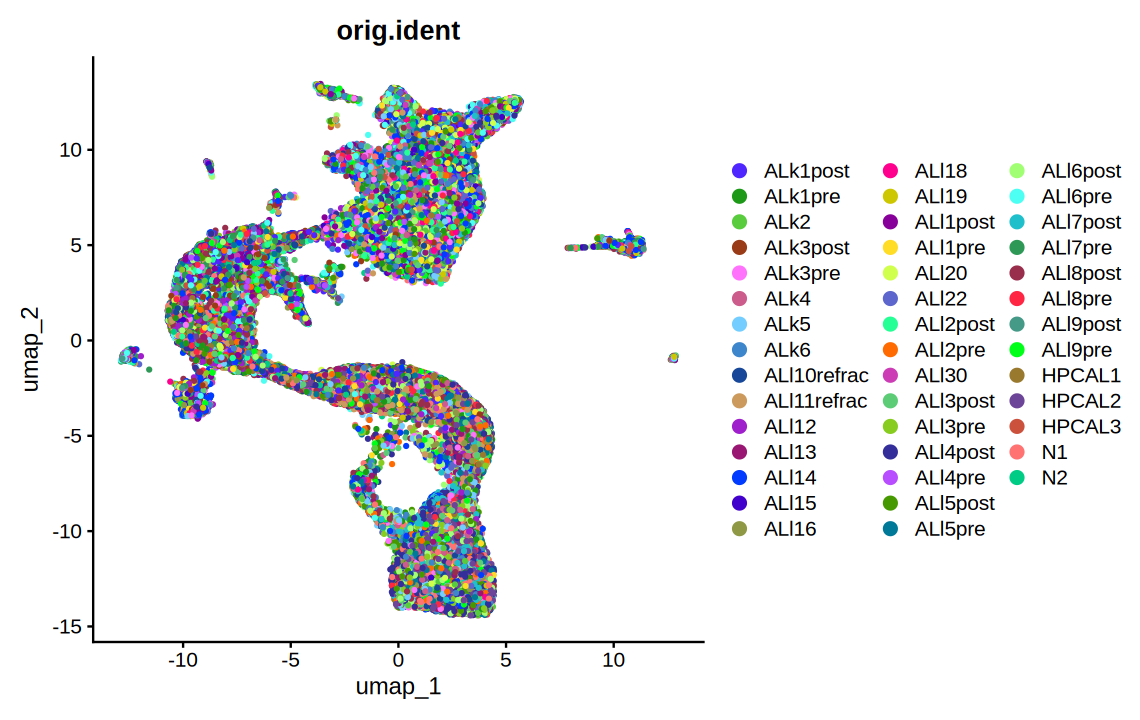

In [4]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9.5)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("orig.ident"),label=F) 

In [5]:
library(Seurat)
library(Azimuth)

# Your object: must contain raw counts in RNA (default) assay
# e.g., obj <- Read10X("path/to/filtered_feature_bc_matrix/") |> CreateSeuratObject()

# Optional: basic QC/feature calc (doesn't affect Azimuth’s internal normalization)
# obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")

# Run Azimuth mapping. Reference key for human BM is "bonemarrowref".
bm_anno <- RunAzimuth(
  query     = sce1_myeloid,
  reference = "bonemarrowref"   # Azimuth will fetch the HuBMAP Bone Marrow reference
)

# The returned object is your query with added predictions & projected UMAPs.
bm_anno


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



Attaching shinyBS

Warning message:
"Overwriting miscellanous data for model"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
detected inputs from HUMAN with id type Gene.name

reference rownames detected HUMAN with id type Gene.name

Normalizing query using reference SCT model

Warning message:
"28 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 2972 features."
Projecting cell embeddings

Finding query neighbors

Finding neighborhoods

Finding anchors

	Found 30083 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Predict

An object of class Seurat 
36650 features across 139776 samples within 3 assays 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.celltype.l2, prediction.score.celltype.l1
 6 dimensional reductions calculated: pca, UMAP, harmony, umap, integrated_dr, ref.umap

## 2. Visualization and figure generation


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



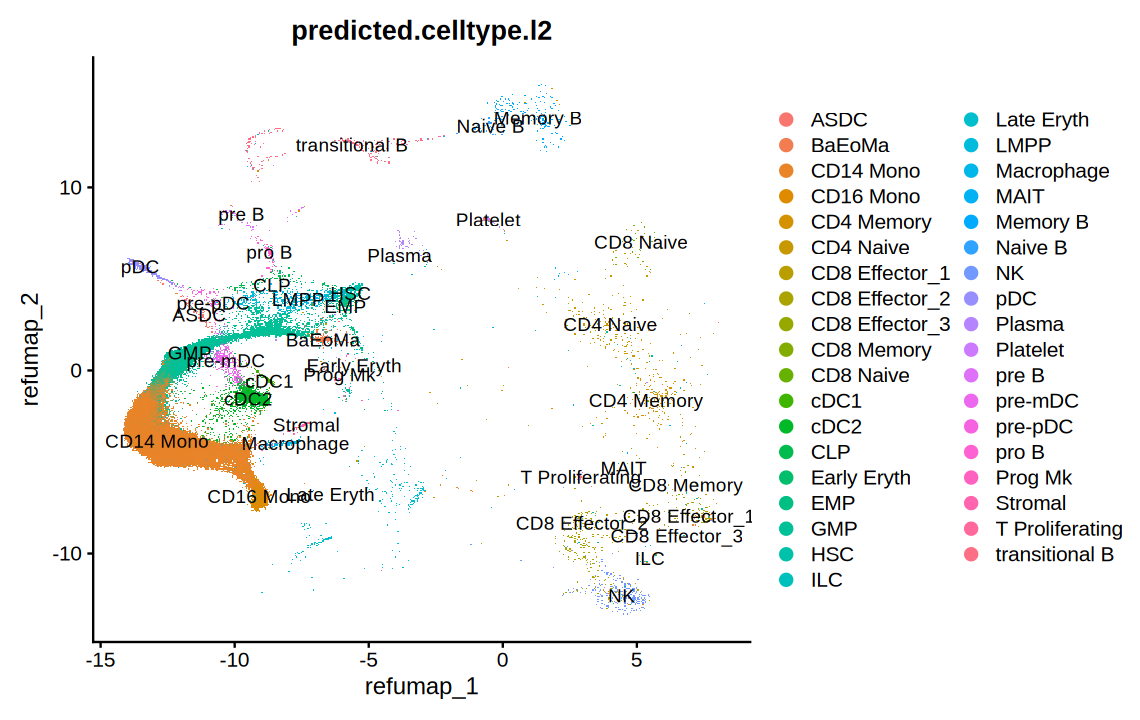

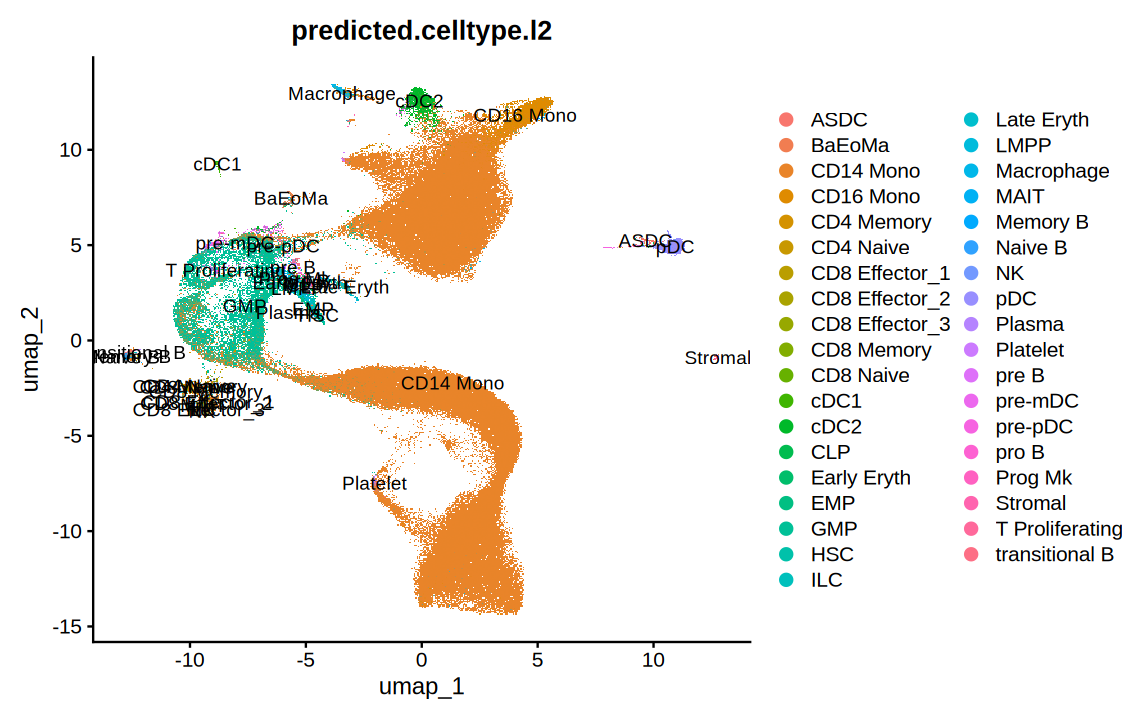

In [6]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



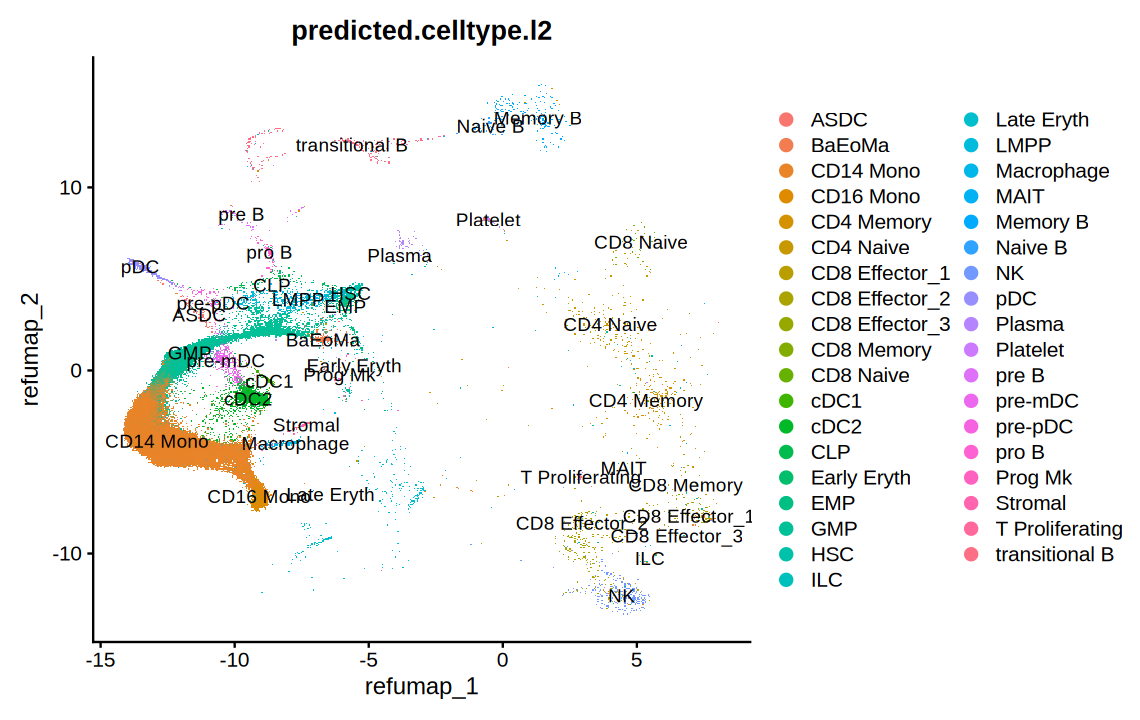

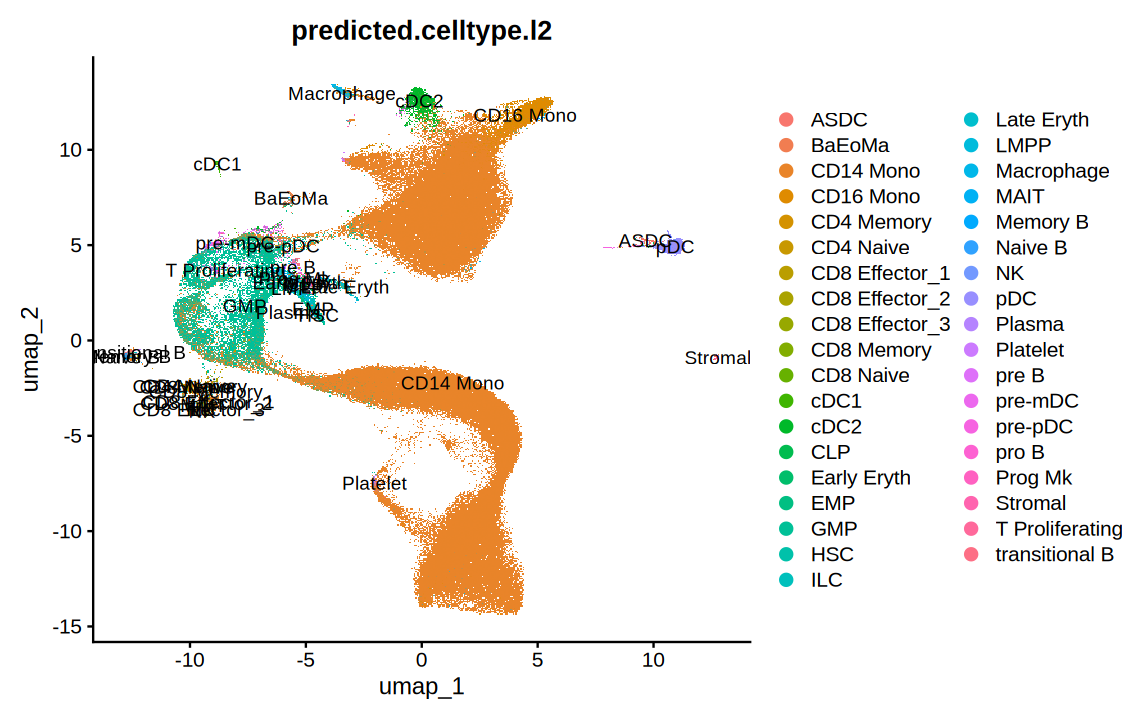

In [7]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

In [8]:
# Flag low-confidence predictions (tune the cutoff for your data)
bm_anno$low_conf <- bm_anno$predicted.celltype.l2.score < 0.5
table(bm_anno$low_conf)

# You can drop or re-cluster low-confidence cells if needed
bm_anno <- subset(bm_anno, subset = predicted.celltype.l2.score >= 0.5)



 FALSE   TRUE 
137858   1918 

## 3. Visualize on the projected reference UMAP


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



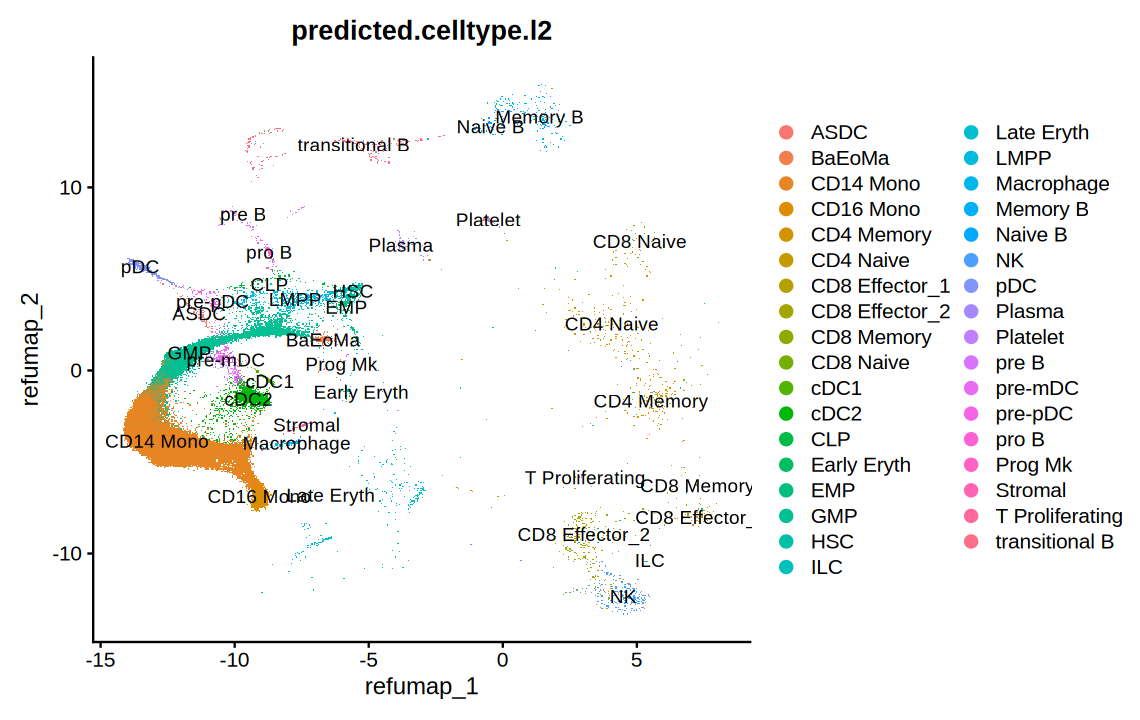

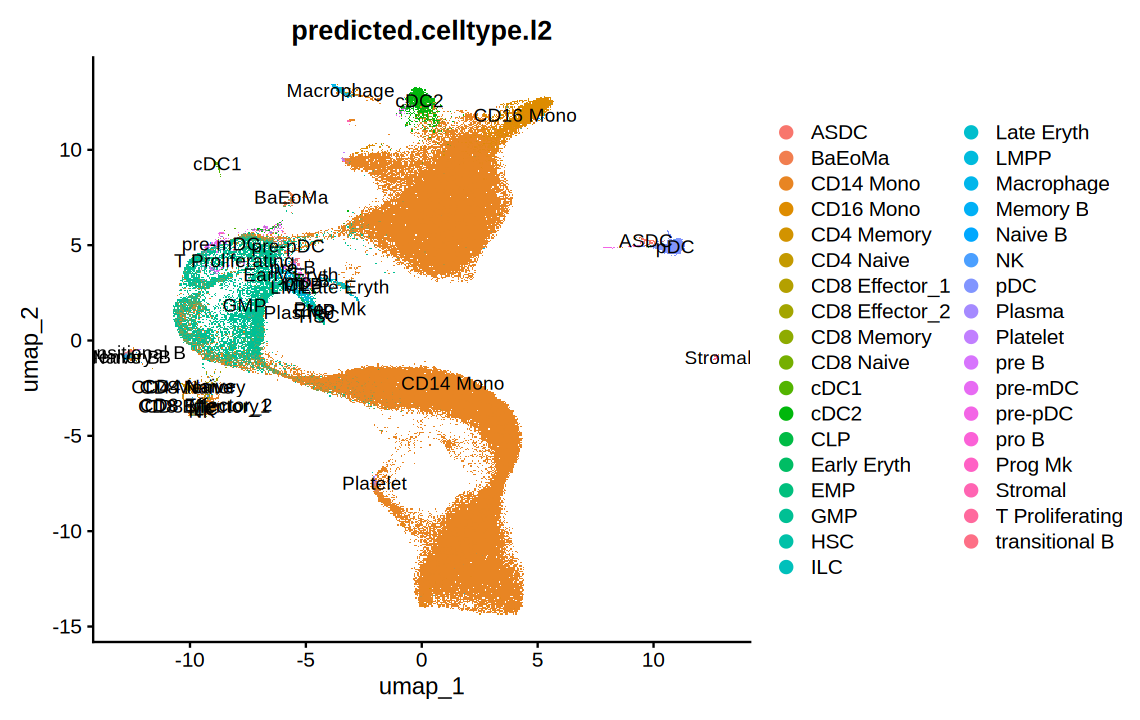

In [9]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

In [10]:
# 1) Make sure identities are the Azimuth labels (adjust the column name if needed)
Idents(bm_anno) <- "predicted.celltype.l2"

# 2) Define your targets (as a proper character vector)
targets <- c(
  "ASDC","CD14 Mono","CD16 Mono","cDC2","cDC1","LMPP",
  "GMP","HSC","pDC","pre-mDC","pre-pDC","Macrophage"
)

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
bm_anno_myeloid <- subset(bm_anno, idents = keep)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



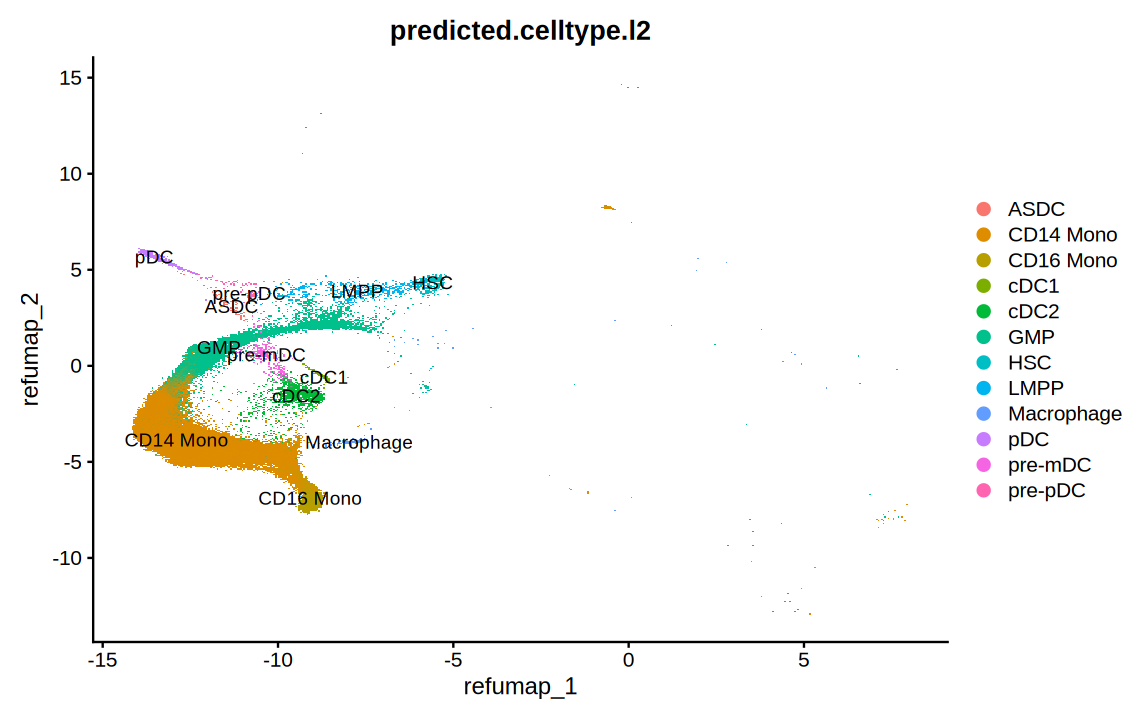

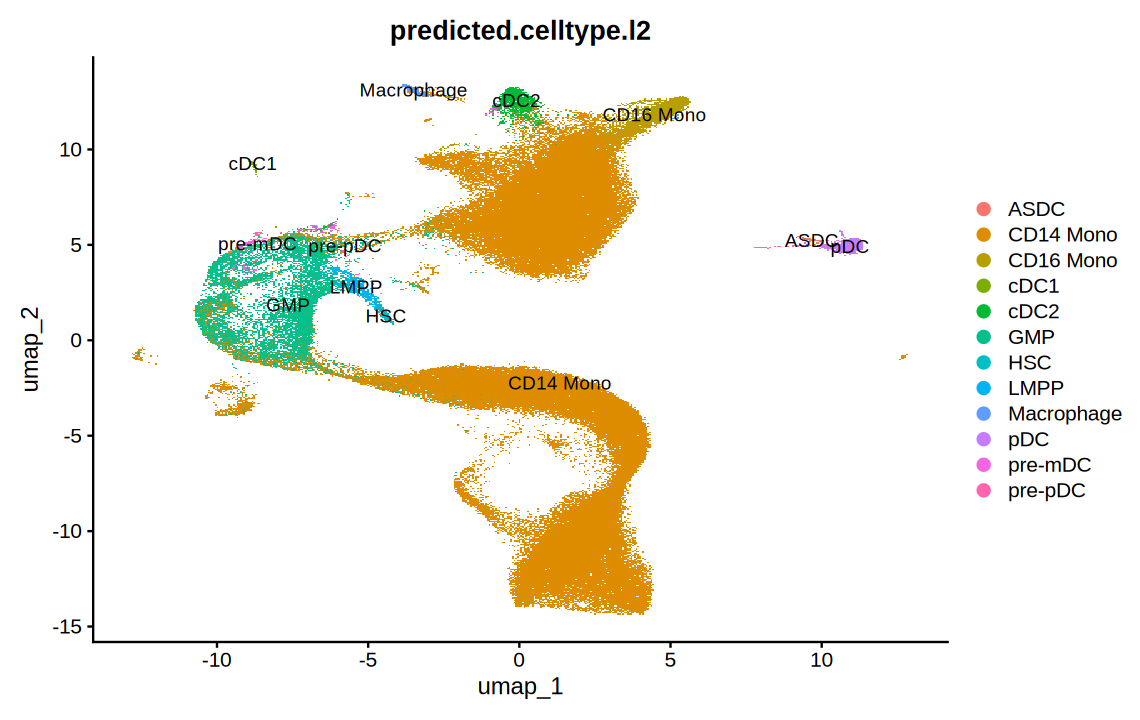

In [11]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno_myeloid, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno_myeloid, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

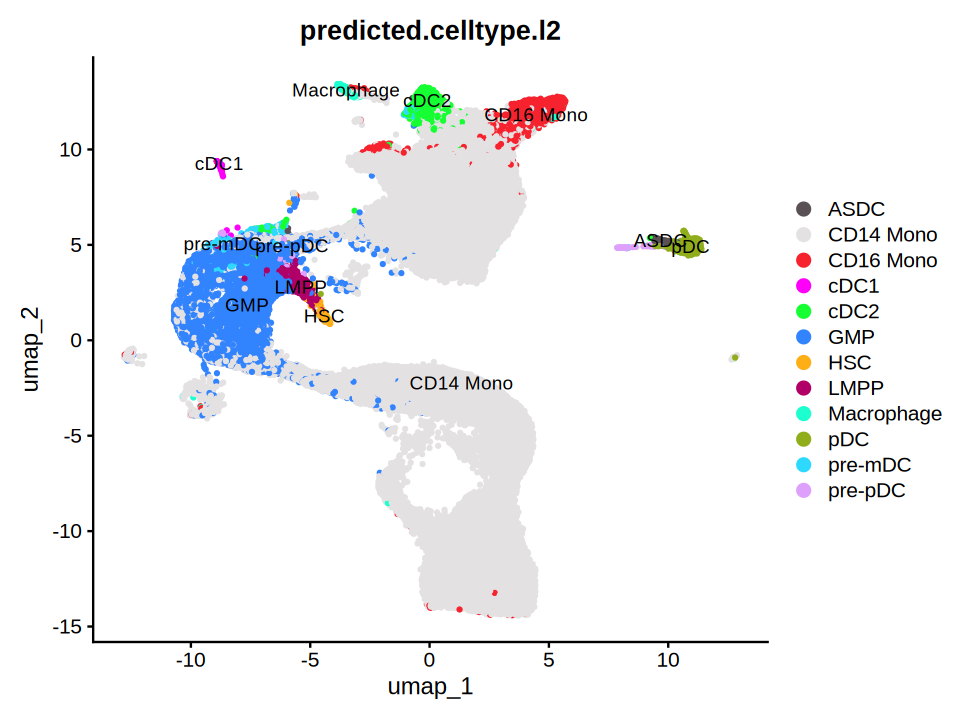

In [12]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("predicted.celltype.l2"),label=T) 

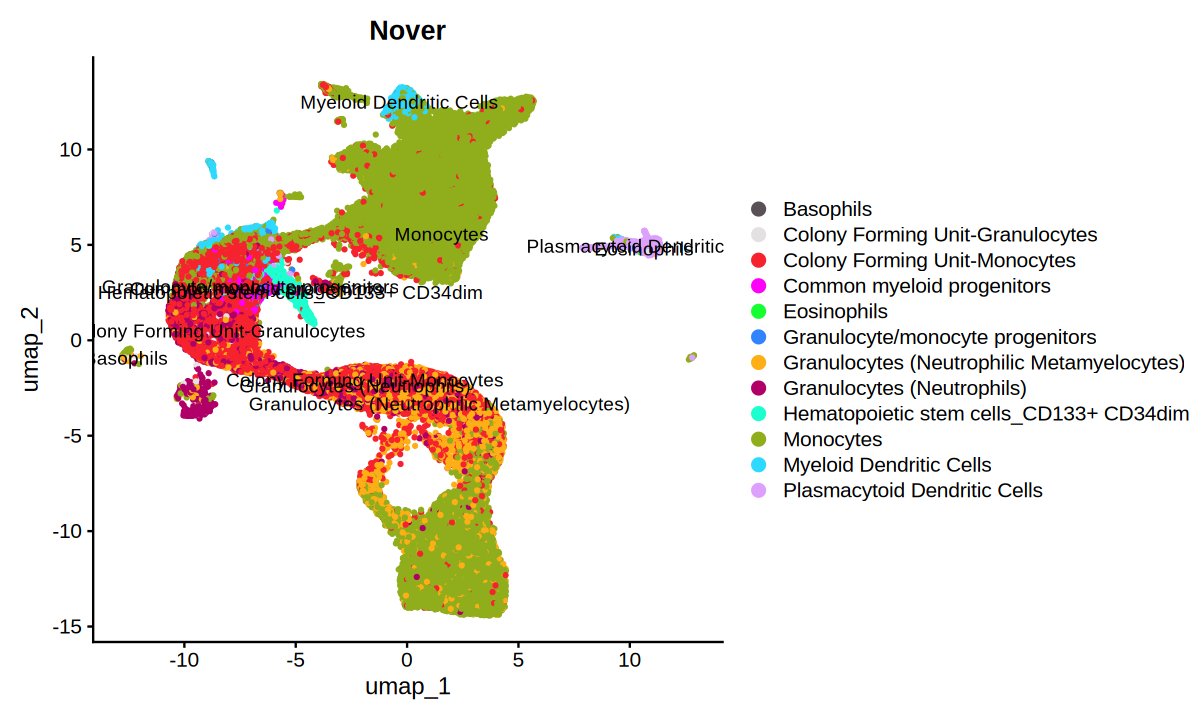

In [13]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("Nover"),label=T) 

## 4. Cell-type annotation


In [14]:
library(dplyr)

mlab <- as.character(bm_anno_myeloid$predicted.celltype.l2)
lab0 <- as.character(bm_anno_myeloid$Nover)

final <- case_when(
  !is.na(lab0) & lab0 == "Colony Forming Unit-Monocytes" ~ "Colony Forming Unit-Monocytes",
  !is.na(lab0) & lab0 == "Colony Forming Unit-Granulocytes" ~ "Colony Forming Unit-Granulocytes",
  !is.na(lab0) & lab0 == "Granulocytes (Neutrophils)" ~ "Granulocytes (Neutrophils)",
  TRUE ~ mlab   # default: keep multinomial label
)

# fallback: if final is NA/blamyeloid, use original label
final[is.na(final) | final == ""] <- lab0[is.na(final) | final == ""]

bm_anno_myeloid$final_label <- factor(final, levels = sort(unique(final)))


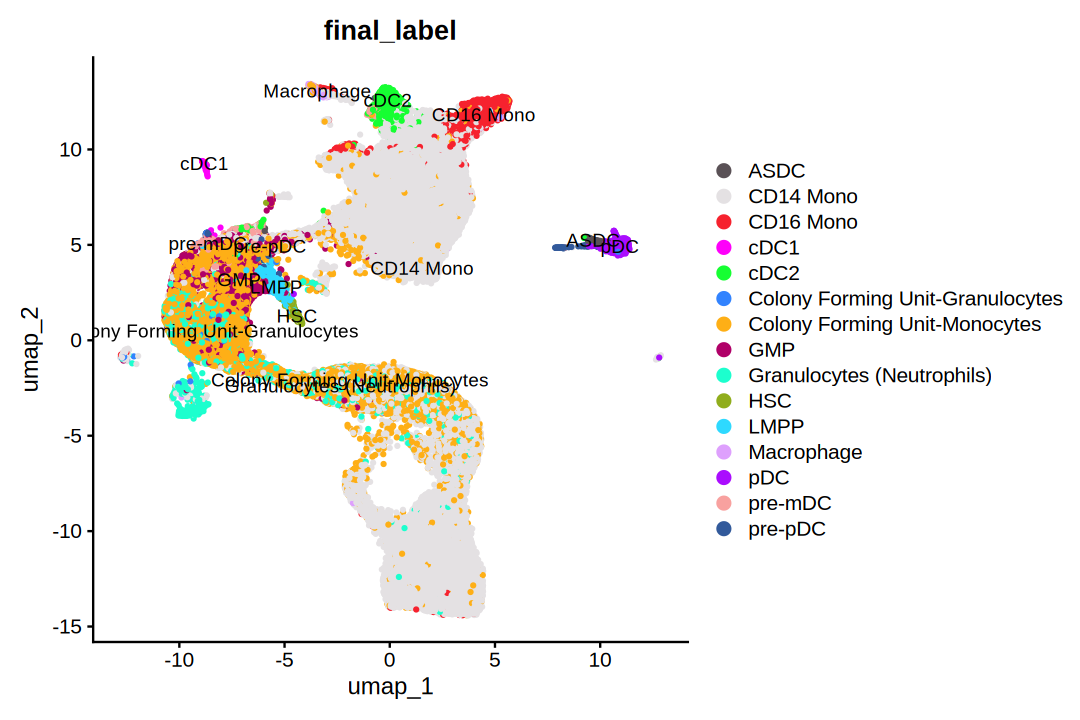

In [15]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T) 

In [16]:
p <- DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T) 
ggsave("Fig5A.pdf", plot = p, width = 9, height =6)


## 5. Packages and reproducibility setup


In [17]:
Idents(bm_anno_myeloid) <- "final_label"  

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene <- c(
    #HSC
    "CD34",
    # mono/macro
    "VCAN","THBS1","S1PR3","CD36","ALDH1A1","CYP1B1","NRG1",
    # neutrophil
    "CXCR1","CXCR2","FCGR3B","MME","PI3","G0S2",
    # immature
    "MPO","ELANE","PRTN3","AZU1","CTSG","DEFA4","OLR1",
    # mature
    "FCGR3B","MME","CXCR1","CXCR2","CEACAM8",
    # proliferating
    "CDC20","UBE2C","BIRC5","CENPA",
    # kuffer-like?cDC2?
    "CD14","CD163","CLEC10A","NOTCH2","ITGAM","SIRPA","CX3CR1","CD1C",
    # dendritic
    "CD1C","CD1E","FCER1A","CLEC10A","CCR6","NDRG2","PKIB","GRIP1","XCR1",
    # plasmatoid
    "CLEC4C","LILRB4","NRP1",
    "CD38"
)



In [18]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(bm_anno_myeloid, features = unique(allgene), scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




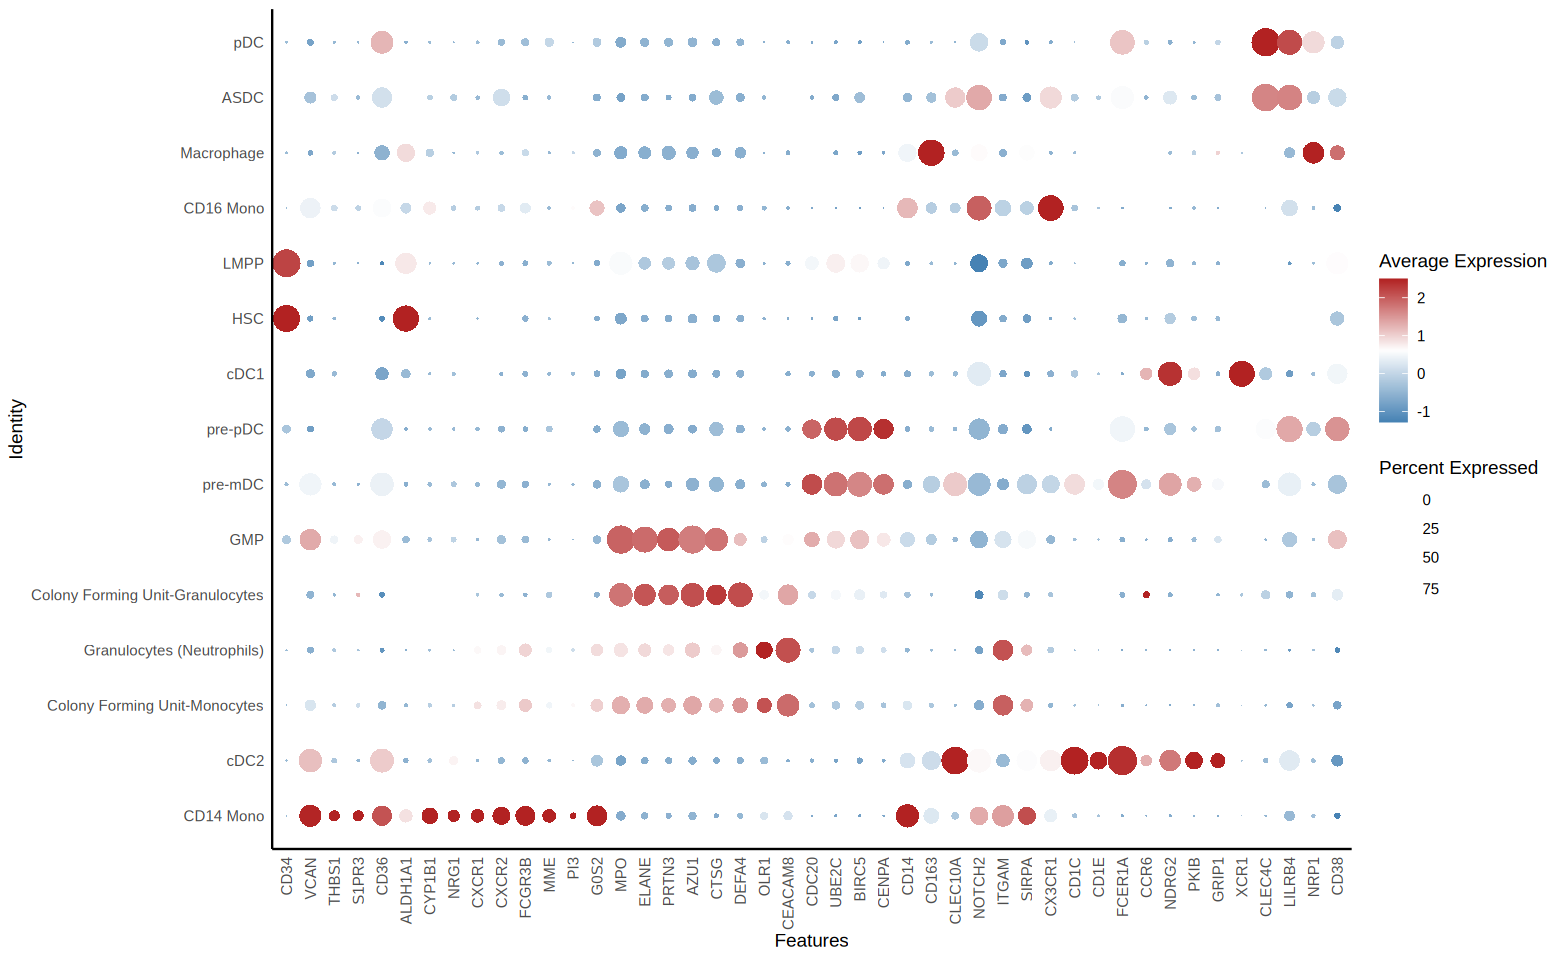

In [19]:
options(repr.plot.height=8,repr.plot.width=13)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


In [20]:
ggsave("FigS11E.pdf", plot = p, width = 11, height =6)

In [21]:
library(msigdbr)
library(dplyr)
library(readr)

monocytes <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_MONOCYTE_CHEMOTAXIS") %>%
  distinct(gene_symbol)

neutrophils <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_NEUTROPHIL_CHEMOTAXIS") %>%
  distinct(gene_symbol)

write_csv(monocytes, "GO_monocyte_chemotaxis_genes_MSigDB.csv")
write_csv(neutrophils,   "GO_neutrophil_chemotaxis_genes_MSigDB.csv")


## 6. Pathway and gene-set enrichment


Loading required package: grid

Loading required package: futile.logger



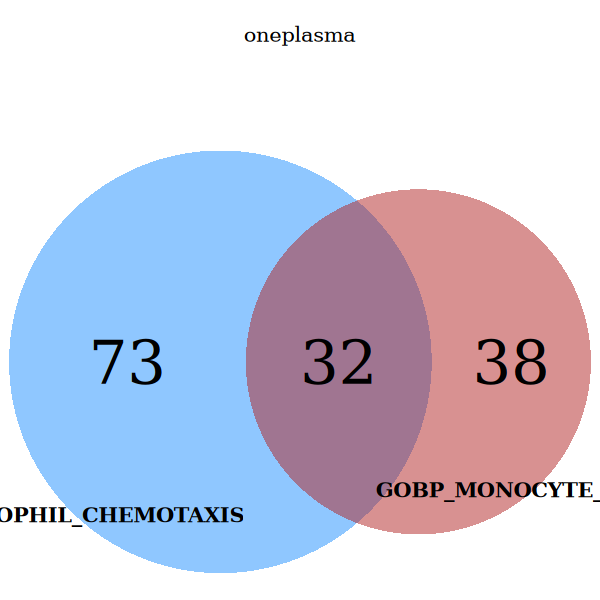

In [22]:
library(VennDiagram)
options(repr.plot.height=5,repr.plot.width=5)
input<-list(monocytes$"gene_symbol",neutrophils$"gene_symbol")
Table<-calculate.overlap(input)
venn<-venn.diagram(main='oneplasma',input,NULL, cat.fontface = "bold",cat.cex = 1,cex = 3,
category = c('GOBP_MONOCYTE_CHEMOTAXIS',"GOBP_NEUTROPHIL_CHEMOTAXIS"),fill = c( "firebrick",'dodgerblue'),lty='blank',
cat.col= 'black',   imagetype = "tiff",  main.fontfamily="serif") #, filename = "Vennup.tif"
grid.draw(venn)

$a1
 [1] "AIF1"         "ANO6"         "ANXA1"        "CALCA"        "CCL1"        
 [6] "CCL11"        "CCL13"        "CCL14"        "CCL15"        "CCL16"       
[11] "CCL17"        "CCL18"        "CCL19"        "CCL2"         "CCL20"       
[16] "CCL21"        "CCL22"        "CCL23"        "CCL24"        "CCL25"       
[21] "CCL26"        "CCL3"         "CCL3L1"       "CCL3L3"       "CCL4"        
[26] "CCL5"         "CCL7"         "CCL8"         "CCN3"         "CCR1"        
[31] "CCR2"         "CREB3"        "CTSG"         "CX3CL1"       "CX3CR1"      
[36] "CXCL10"       "CXCL12"       "CXCL17"       "DEFB104A"     "DEFB104B"    
[41] "DEFB124"      "DUSP1"        "FLT1"         "FOLR2"        "FPR2"        
[46] "GREM1"        "HMGB1"        "IL6"          "IL6R"         "LGALS3"      
[51] "LGMN"         "LYN"          "MICOS10-NBL1" "MOSPD2"       "MSMP"        
[56] "NBL1"         "PDGFB"        "PLA2G7"       "PTPRO"        "RPS19"       
[61] "S100A12"      "S100A14"      "

pdf 
  2

pdf 
  2

Saved: Vennup.tif and Vennup.pdf



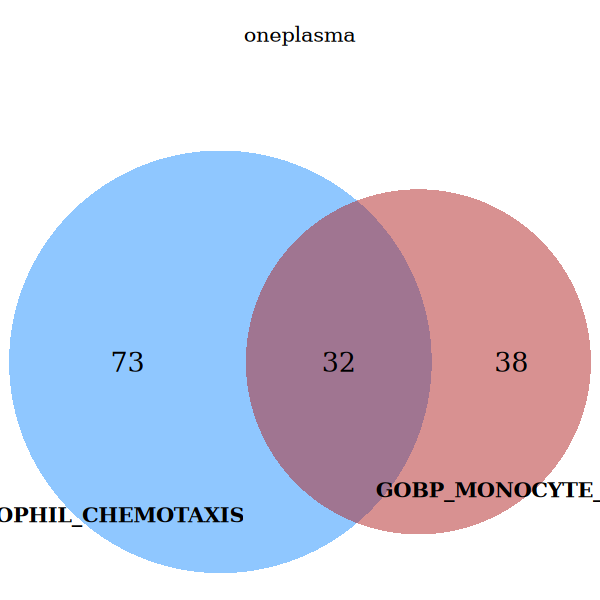

In [23]:
suppressPackageStartupMessages({
  library(VennDiagram)
  library(grid)
})

options(repr.plot.height = 5, repr.plot.width = 5)

# ---------------------------
# Inputs
# ---------------------------
input <- list(
  monocytes   = monocytes$gene_symbol,
  neutrophils = neutrophils$gene_symbol
)

# Optional: remove NAs/duplicates for cleaner counts
input <- lapply(input, function(x) unique(na.omit(x)))

# ---------------------------
# Compute overlap table (if you want it)
# ---------------------------
Table <- calculate.overlap(input)
print(Table)

# ---------------------------
# Draw to the active device (notebook)
# ---------------------------
venn <- venn.diagram(
  x = input,
  filename = NULL,                 # IMPORTANT: render to current device
  main = "oneplasma",
  category.names = c("GOBP_MONOCYTE_CHEMOTAXIS", "GOBP_NEUTROPHIL_CHEMOTAXIS"),
  cat.fontface = "bold",
  cat.cex = 1,
  cex = 1.3,                       # text size inside circles
  fill = c("firebrick", "dodgerblue"),
  lty = "blank",
  cat.col = "black",
  main.fontfamily = "serif"
)

grid.newpage()
grid.draw(venn)

# ---------------------------
# Export as TIFF (recommended for journals)
# ---------------------------
out_tiff <- "Vennup.tif"
tiff(out_tiff, width = 1600, height = 1600, res = 300, compression = "lzw")
grid.newpage()
grid.draw(venn)
dev.off()

# ---------------------------
# (Optional) Export as PDF too
# ---------------------------
out_pdf <- "Vennup.pdf"
pdf(out_pdf, width = 5, height = 5)
grid.newpage()
grid.draw(venn)
dev.off()

message("Saved: ", out_tiff, " and ", out_pdf)


In [24]:
## ---- 0) Gene sets ----
geneset1 <- monocytes$"gene_symbol"     # mono/macrophage-like
geneset2 <- neutrophils$"gene_symbol"                 # neutrophil-like

## ---- 1) Add scores to the original object ----
# Columns will be Set11 and Set21 in meta.data
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset1), name = "Set1")
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset2), name = "Set2")


Warning message:
"The following features are not present in the object: CCL3L3, MICOS10-NBL1, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: CCL3L3, CD300H, MIR223, not searching for symbol synonyms"


## 7. CONFIG


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=47.5%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=47.5%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=47.5%' in 'mbcsToSbcs': dot substituted for <92>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=47.5%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=47.5%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call.graphics(C

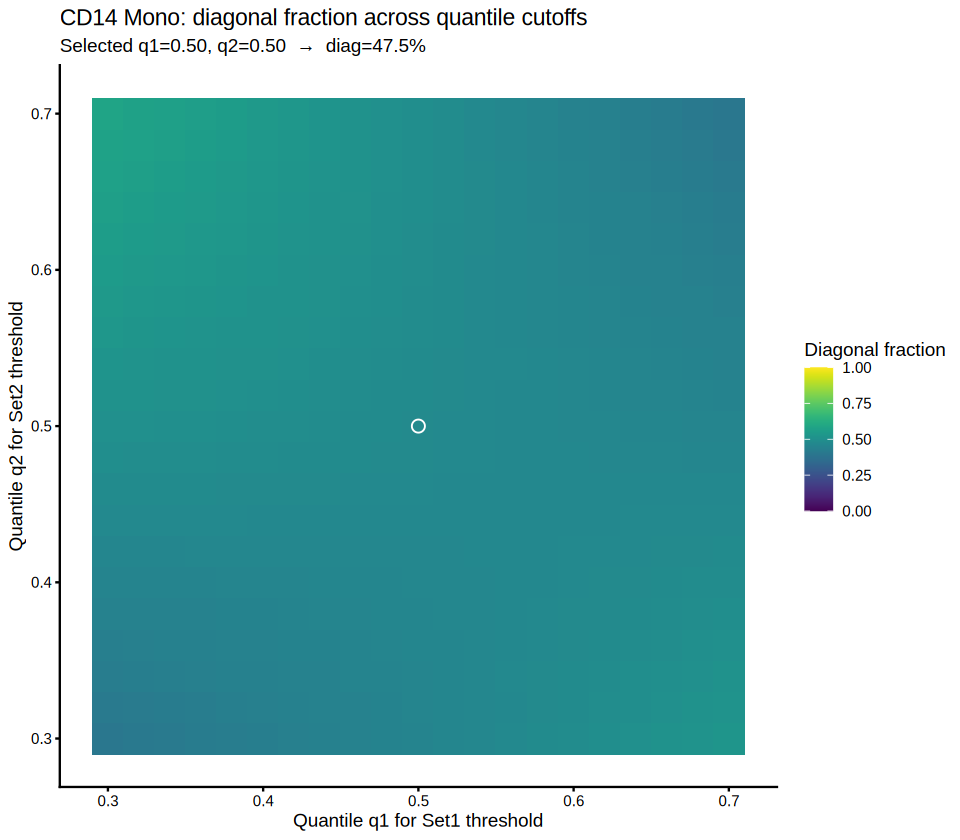

Final (per-set) diagonal fraction in CD14 Mono: 47.5%




set1High_set2High  set1High_set2Low  set1Low_set2High   set1Low_set2Low 
            24382             22054             22054             24382 


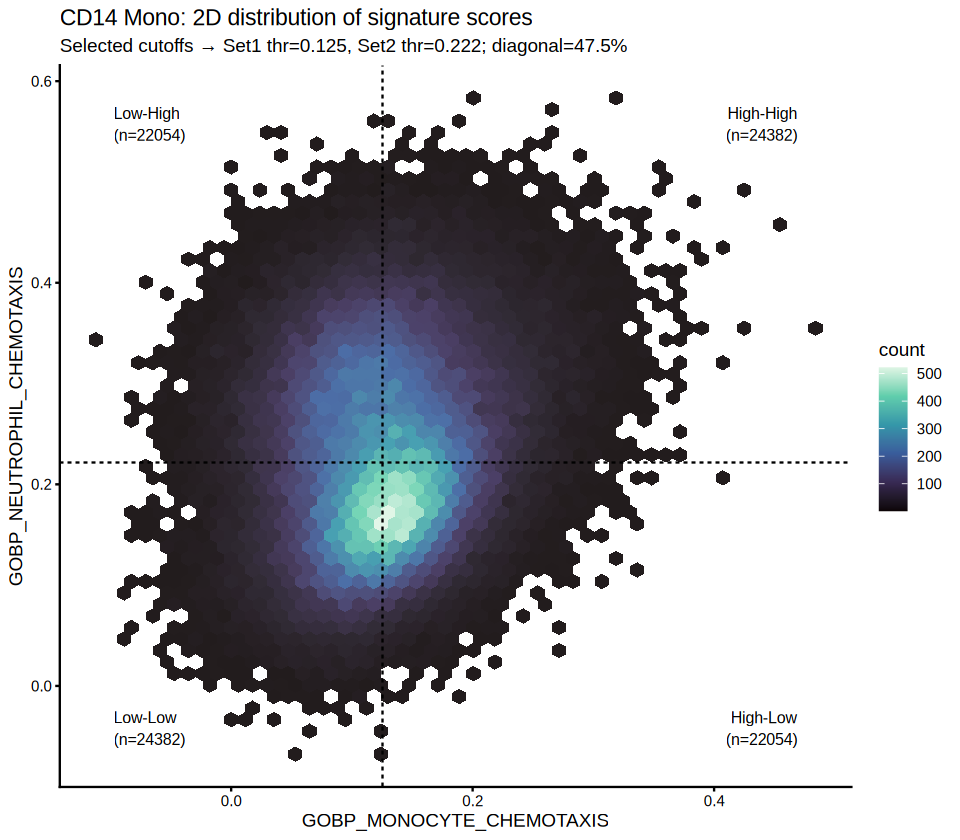

In [25]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(viridis)
  library(purrr)
})

options(repr.plot.height=7, repr.plot.width=8)

# ======================== CONFIG =========================
anno_col   <- "final_label"
cell_type  <- "CD14 Mono"
MODE       <- "maximize"   # "maximize" or "enforce"
TARGET     <- 0.60         # used when MODE == "enforce" (min diagonal fraction)
USE_DIFF_MODE <- TRUE      # also try the |Set1-Set2| gap method

# ==================== PREPARE DATA =======================
is_ct <- bm_anno_myeloid@meta.data[[anno_col]] == cell_type

df <- bm_anno_myeloid@meta.data %>%
  tibble::as_tibble(rownames = "cell") %>%
  filter(.data[[anno_col]] == !!cell_type) %>%
  transmute(cell,
            set1 = Set11,
            set2 = Set21) %>%
  filter(is.finite(set1), is.finite(set2))

stopifnot(nrow(df) > 0)

use_hex <- nrow(df) > 20000

# Helper: compute diagonal fraction for given numeric thresholds
diag_prop_from_thresholds <- function(s1, s2, thr1, thr2) {
  lab1 <- ifelse(s1 >= thr1, "set1High", "set1Low")
  lab2 <- ifelse(s2 >= thr2, "set2High", "set2Low")
  mean((lab1 == "set1High" & lab2 == "set2Low") |
       (lab1 == "set1Low"  & lab2 == "set2High"),
       na.rm = TRUE)
}

# ================== GRID OVER QUANTILES ==================
s1 <- df$set1; s2 <- df$set2
q_grid1 <- seq(0.30, 0.70, by = 0.02)
q_grid2 <- seq(0.30, 0.70, by = 0.02)

grid_tbl <- tidyr::crossing(q1 = q_grid1, q2 = q_grid2) %>%
  mutate(
    thr1 = as.numeric(map_dbl(q1, ~ quantile(s1, .x, na.rm = TRUE))),
    thr2 = as.numeric(map_dbl(q2, ~ quantile(s2, .x, na.rm = TRUE))),
    prop_diag = pmap_dbl(list(thr1, thr2), ~ diag_prop_from_thresholds(s1, s2, ..1, ..2)),
    dist_to_med = abs(q1 - 0.5) + abs(q2 - 0.5)  # used for tie-breakers / "enforce"
  )

# ======== FORCE MEDIAN CUTOFFS ON X & Y (Set1, Set2) ========
thr1 <- median(s1, na.rm = TRUE)
thr2 <- median(s2, na.rm = TRUE)
prop_diag_q <- diag_prop_from_thresholds(s1, s2, thr1, thr2)

# keep a fake "best_row" at q1=q2=0.5 so the heatmap still shows a white dot at the median
best_row <- tibble::tibble(
  q1 = 0.50, q2 = 0.50,
  thr1 = thr1, thr2 = thr2,
  prop_diag = prop_diag_q,
  dist_to_med = 0
)


# ============== HEATMAP of diagonal proportion ===========
p_heat <- ggplot(grid_tbl, aes(q1, q2, fill = prop_diag)) +
  geom_tile() +
  scale_fill_viridis(name = "Diagonal fraction", limits = c(0,1)) +
  geom_point(data = best_row, aes(q1, q2), color = "white", size = 3, shape = 21, stroke = 0.6) +
  labs(x = "Quantile q1 for Set1 threshold",
       y = "Quantile q2 for Set2 threshold",
       title = paste0(cell_type, ": diagonal fraction across quantile cutoffs"),
       subtitle = sprintf("Selected q1=%.2f, q2=%.2f  →  diag=%.1f%%",
                          best_row$q1, best_row$q2, 100*prop_diag_q)) +
  theme_classic()

# ============== SCATTER/HEX with chosen thresholds ==========
# Quadrant labeling for the chosen thr1, thr2
df_quads <- df %>%
  mutate(
    quad = case_when(
      set1 >= thr1 & set2 >= thr2 ~ "High-High",
      set1 >= thr1 & set2 <  thr2 ~ "High-Low",
      set1 <  thr1 & set2 >= thr2 ~ "Low-High",
      TRUE                        ~ "Low-Low"
    )
  )

qcounts <- df_quads %>%
  count(quad) %>%
  tidyr::complete(quad = c("High-High","High-Low","Low-High","Low-Low"), fill = list(n = 0))

padx <- (max(df$set1, na.rm=TRUE) - min(df$set1, na.rm=TRUE)) * 0.02
pady <- (max(df$set2, na.rm=TRUE) - min(df$set2, na.rm=TRUE)) * 0.02

labpos <- tibble::tibble(
  quad = c("High-High","High-Low","Low-High","Low-Low"),
  x = c(max(df$set1, na.rm=TRUE) - padx, max(df$set1, na.rm=TRUE) - padx,
        min(df$set1, na.rm=TRUE) + padx, min(df$set1, na.rm=TRUE) + padx),
  y = c(max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady,
        max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady),
  hjust = c(1,1,0,0),
  vjust = c(1,0,1,0)
) %>% left_join(qcounts, by = "quad") %>%
  mutate(label = paste0(quad, "\n(n=", n, ")"))

p_scatter <- ggplot(df_quads, aes(x = set1, y = set2)) +
  { if (use_hex) geom_hex(bins = 50, alpha = 0.9) else
      geom_point(aes(color = quad), alpha = 0.5, size = 0.6) } +
  geom_vline(xintercept = thr1, linetype = "dashed") +
  geom_hline(yintercept = thr2, linetype = "dashed") +
  labs(x = "GOBP_MONOCYTE_CHEMOTAXIS", y = "GOBP_NEUTROPHIL_CHEMOTAXIS",
       title = paste0(cell_type, ": 2D distribution of signature scores"),
       subtitle = sprintf("Selected cutoffs → Set1 thr=%.3f, Set2 thr=%.3f; diagonal=%.1f%%",
                          thr1, thr2, 100*prop_diag_q)) +
  theme_classic() +
  { if (use_hex) scale_fill_viridis_c(option = "mako") else
      scale_color_viridis_d(option = "mako") } +
  geom_text(data = labpos, aes(x = x, y = y, label = label, hjust = hjust, vjust = vjust),
            size = 3.2)


# ================== PRINT / SAVE ==================
print(p_heat)
print(p_scatter)

# ================== WRITE TAGS BACK (optional) =================
# Use the selected per-set thresholds (q1,q2) for labeling
grp1_all <- ifelse(bm_anno_myeloid@meta.data$Set11 >= thr1, "set1High", "set1Low")
grp2_all <- ifelse(bm_anno_myeloid@meta.data$Set21 >= thr2, "set2High", "set2Low")

orig_lab <- as.character(bm_anno_myeloid@meta.data[[anno_col]])
tag_lab  <- ifelse(bm_anno_myeloid@meta.data[[anno_col]] == cell_type,
                   paste0(cell_type, "_", grp1_all, "_", grp2_all),
                   orig_lab)

bm_anno_myeloid$CD14_tag <- NA_character_
bm_anno_myeloid$CD14_tag[is_ct] <- paste0(grp1_all[is_ct], "_", grp2_all[is_ct])
bm_anno_myeloid$Annotation <- tag_lab

# Quick sanity checks
tab_cd14 <- table(bm_anno_myeloid$CD14_tag[is_ct], useNA = "ifany")
diag_prop_final <- sum(tab_cd14[c("set1High_set2Low","set1Low_set2High")], na.rm = TRUE) / sum(tab_cd14)
message(sprintf("Final (per-set) diagonal fraction in %s: %.1f%%", cell_type, 100*diag_prop_final))
print(tab_cd14)



In [26]:
# ================== EXPORT PDFs (separate files) ==================
out_dir <- "figures_pdf"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

safe_ct <- gsub("[^A-Za-z0-9_\\-]+", "_", cell_type)

ggsave(
  filename = file.path(out_dir, paste0(safe_ct, "_diag_fraction_heatmap.pdf")),
  plot = p_heat,
  width = 8, height = 7, units = "in",
  device = cairo_pdf
)

ggsave(
  filename = file.path(out_dir, paste0(safe_ct, "_signature_scatter_or_hex.pdf")),
  plot = p_scatter,
  width = 8, height = 7, units = "in",
  device = cairo_pdf
)


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



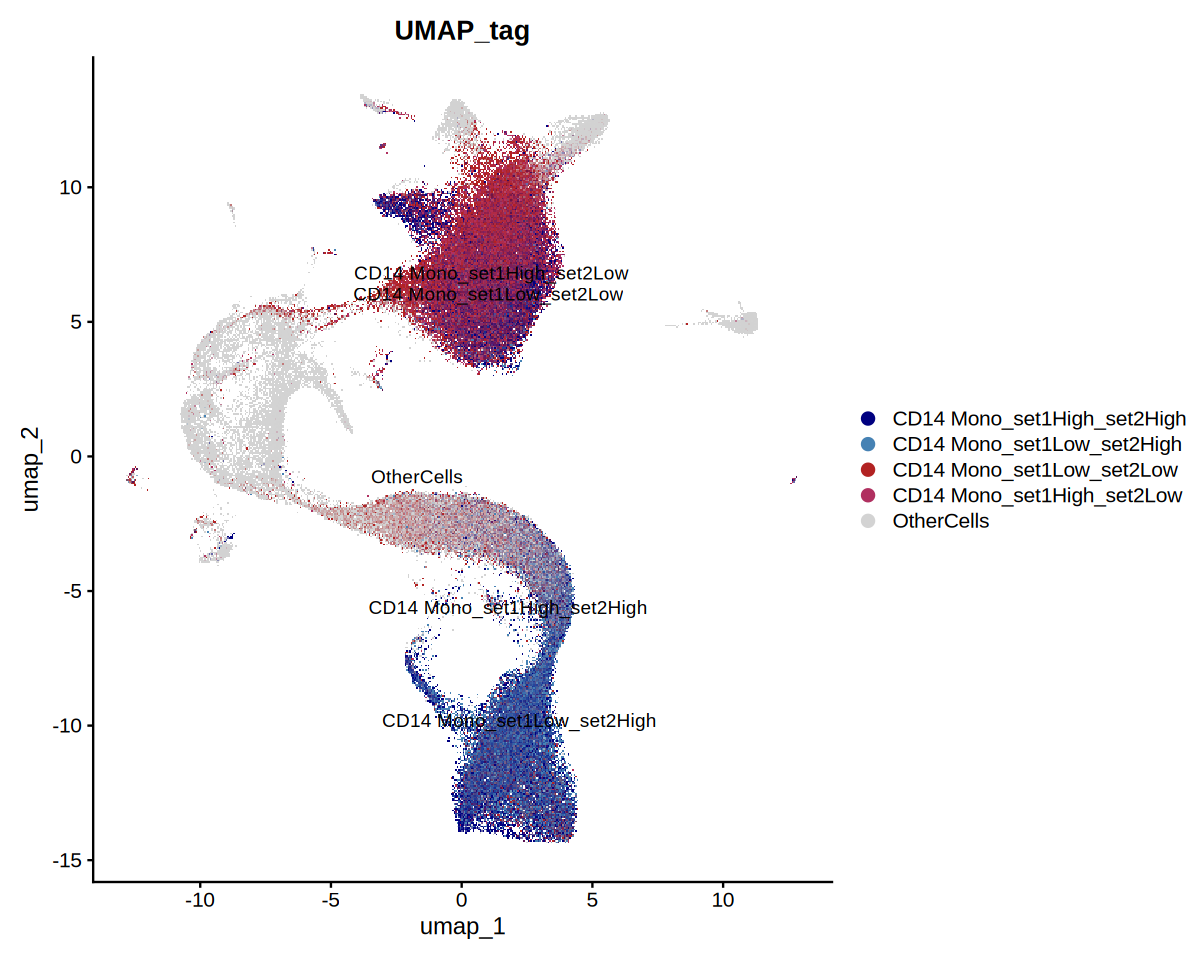

In [27]:
options(repr.plot.height = 8, repr.plot.width = 10)

# 1) Collapse non-CD14 to one label
bm_anno_myeloid$UMAP_tag <- ifelse(
  grepl("^CD14 Mono", bm_anno_myeloid$Annotation),
  bm_anno_myeloid$Annotation,
  "OtherCells"
)

# 2) Get CD14 Mono levels in a stable order
labs        <- unique(bm_anno_myeloid$UMAP_tag)
tag_levels  <- grep("^CD14 Mono", labs, value = TRUE)

# 3) Build the requested color panel for tagged groups
base_panel  <- c("navy", "steelblue", "firebrick", "maroon")
tag_cols    <- base_panel[seq_len(min(length(tag_levels), length(base_panel)))]

# If more CD14 groups than colors, recycle (or swap to a longer panel as needed)
if (length(tag_levels) > length(tag_cols)) {
  tag_cols <- rep(base_panel, length.out = length(tag_levels))
}

# 4) Set plotting order: all CD14 groups first, then "OtherCells"
bm_anno_myeloid$UMAP_tag <- factor(
  bm_anno_myeloid$UMAP_tag,
  levels = c(tag_levels, "OtherCells")
)

# 5) Final palette (OtherCells = lightgrey)
plot_cols <- c(tag_cols, "lightgrey")

# 6) Plot
DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
)


In [28]:
library(Seurat)
library(scCustomize)
library(patchwork)
library(ggplot2)

# Same UMAP coordinate limits for both plots
umap_mat <- Embeddings(bm_anno_myeloid, reduction = "umap")
xlim_use <- range(umap_mat[, 1], na.rm = TRUE)
ylim_use <- range(umap_mat[, 2], na.rm = TRUE)

p1 <- DimPlot_scCustom(
  bm_anno_myeloid,
  pt.size   = 0.5,
  reduction = "umap",
  group.by  = "predicted.celltype.l2",
  label     = TRUE
) +
  NoLegend() +
  coord_fixed(xlim = xlim_use, ylim = ylim_use) +
  ggtitle("Predicted cell type L2")

p2 <- DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
) +
  NoLegend() +
  coord_fixed(xlim = xlim_use, ylim = ylim_use) +
  ggtitle("UMAP tag")

p_combined <- p1 + p2 + 
  plot_layout(ncol = 2, widths = c(1, 1))

ggsave(
  filename = "bm_anno_myeloid_umap_panels_same_size.pdf",
  plot     = p_combined,
  width    = 10,
  height   = 5,
  units    = "in",
  device   = cairo_pdf
)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



In [29]:
bm_anno_myeloid$label <- bm_anno_myeloid$orig.ident
bm_anno_myeloid$label <- ifelse(grepl("N1|N2", bm_anno_myeloid$label), "Normal", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl9pre|ALl8pre|ALl6pre|ALl30|ALl20|ALl19|ALl18|ALl14|ALl13|ALl1pre|ALk4|ALk1pre", bm_anno_myeloid$label), "AL_CR_pre", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl9post|ALl8post|ALl6post|ALl1post|ALk1post", bm_anno_myeloid$label), "AL_CR_post", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl3pre|ALl22|ALk3pre|ALk2|HPCAL2", bm_anno_myeloid$label), "AL_VGPR_pre", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALk3post|ALl3post", bm_anno_myeloid$label), "AL_VGPR_post", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl7pre|ALl12|ALk6|HPCAL1", bm_anno_myeloid$label), "AL_NR/SD_pre", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl7post", bm_anno_myeloid$label), "AL_NR/SD_post", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl5pre|ALl4pre|ALl2pre|ALl16", bm_anno_myeloid$label), "AL_PR_pre", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("ALl5post|ALl4post|ALl2post|ALl11refrac|ALl10refrac", bm_anno_myeloid$label), "AL_PR_post", bm_anno_myeloid$label)
bm_anno_myeloid$label <- ifelse(grepl("HPCAL3|ALl15|ALk5", bm_anno_myeloid$label), "AL_NotRecorded", bm_anno_myeloid$label)

## 8. Sample metadata and clinical groups


In [30]:
# ============================================================
# Ensure response/treatment labels persist in the parent object
# This prevents downstream subsets from losing these labels.
# ============================================================
library(dplyr)

bm_anno_myeloid$label <- as.character(bm_anno_myeloid$label)
bm_anno_myeloid$label <- gsub("[[:space:]'‘’\"“”]", "", bm_anno_myeloid$label)

label_clean <- bm_anno_myeloid$label

bm_anno_myeloid$response <- case_when(
  grepl("_(pre|post)$", label_clean, perl = TRUE) ~ sub("_(pre|post)$", "", label_clean, perl = TRUE),
  label_clean %in% c("Normal", "AL_NotRecorded") ~ label_clean,
  TRUE ~ label_clean
)

bm_anno_myeloid$treatment <- case_when(
  grepl("_pre$",  label_clean, perl = TRUE) ~ "Pre",
  grepl("_post$", label_clean, perl = TRUE) ~ "Post",
  TRUE ~ NA_character_
)

message("response/treatment labels added to bm_anno_myeloid")
print(table(bm_anno_myeloid$response, bm_anno_myeloid$treatment, useNA = "ifany"))


response/treatment labels added to bm_anno_myeloid



                
                  Post   Pre  <NA>
  AL_CR          19511 33876     0
  AL_NotRecorded     0     0  6831
  AL_NR/SD        3744 10270     0
  AL_PR          21130 10743     0
  AL_VGPR         6548 16789     0
  Normal             0     0  5600


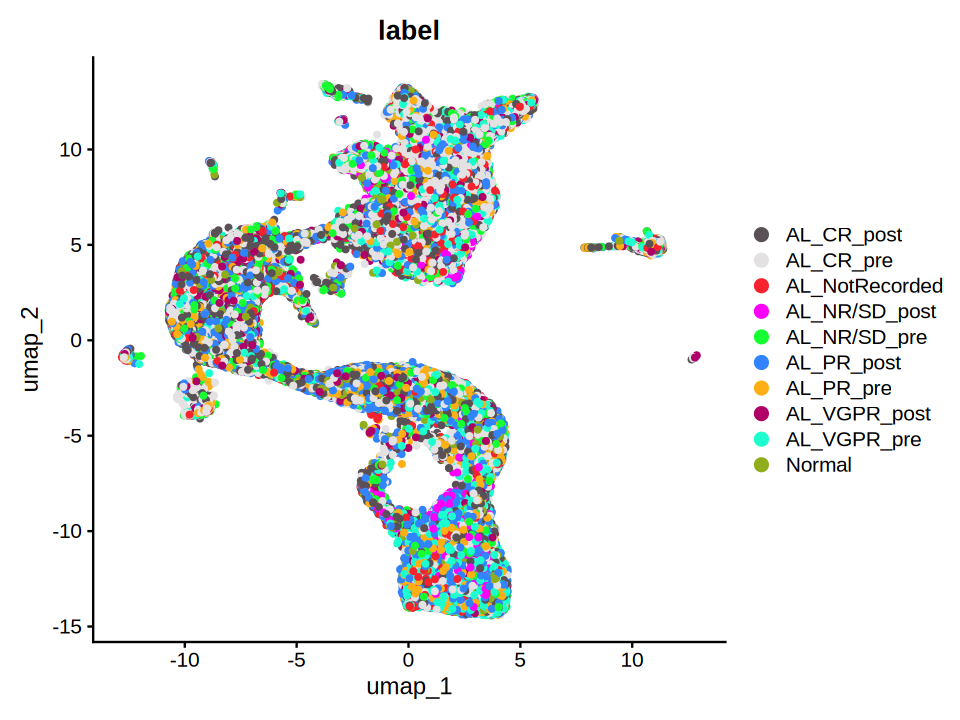

In [31]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(bm_anno_myeloid , pt.size=1,reduction = "umap", group.by = c("label"),label=F) 


Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:viridis':

    viridis_pal


The following object is masked from 'package:readr':

    col_factor


# mismatched Pre:  0

# mismatched Post: 0

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `pval = ifelse(...)`.
ℹ In row 72.
Caused by warning in `chisq.test()`:
! Chi-squared approximation may be incorrect"


# A tibble: 108 × 6
   response celltype                        pre  post      pval      padj
   <fct>    <fct>                         <int> <int>     <dbl>     <dbl>
 1 AL_CR    CD14 Mono_set1High_set2High    6670  1835 0         0        
 2 AL_CR    CD14 Mono_set1High_set2Low     6399  2639 0         0        
 3 AL_VGPR  CD14 Mono_set1High_set2High    3879   671 0         0        
 4 AL_VGPR  CD14 Mono_set1Low_set2High     4228   976 0         0        
 5 AL_NR/SD Colony Forming Unit-Monocytes  2308    47 0         0        
 6 AL_NR/SD CD14 Mono_set1Low_set2Low      2255    96 0         0        
 7 AL_PR    CD14 Mono_set1High_set2Low     1242  3795 2.29e-283 2.36e-282
 8 AL_PR    CD14 Mono_set1High_set2High    1669  3758 6.88e-177 6.20e-176
 9 AL_VGPR  CD14 Mono_set1High_set2Low     2844  1102 2.93e-169 2.35e-168
10 AL_NR/SD CD14 Mono_set1High_set2Low     1468   386 2.41e-139 1.73e-138
11 AL_CR    CD14 Mono_set1Low_set2Low      6753  4320 2.84e-118 1.86e-117
12 AL_NR/SD Granul

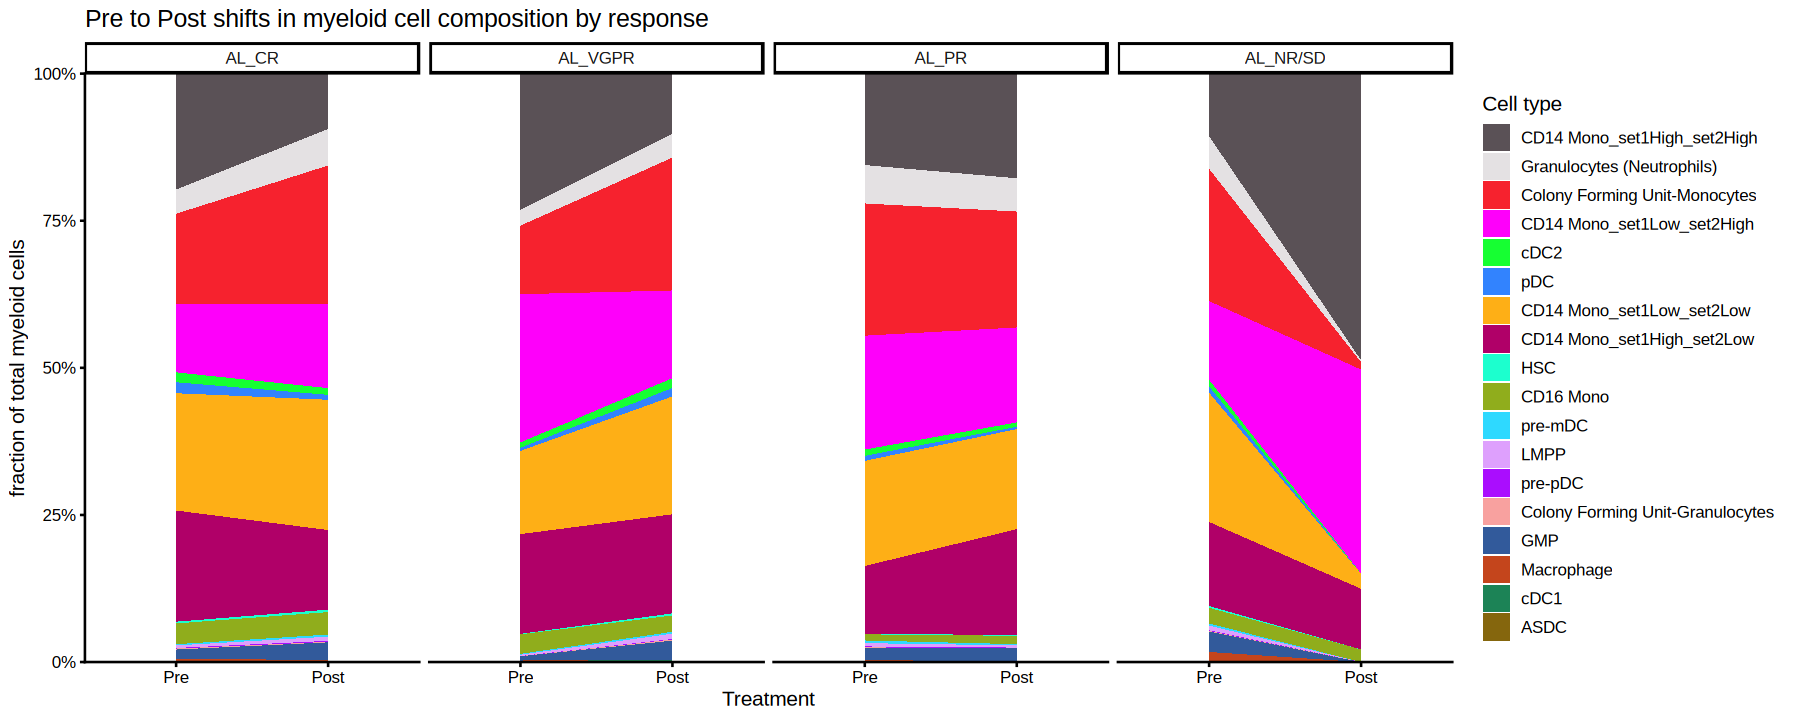

In [32]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(scCustomize)

Idents(bm_anno_myeloid) <- "Annotation"
ct_lvls <- levels(bm_anno_myeloid)
ct_cols <- setNames(
  scCustomize::DiscretePalette_scCustomize(length(ct_lvls), palette = "polychrome"),
  ct_lvls
)

# --- 0) Clean the label column (quotes, spaces, smart quotes) ---
bm_anno_myeloid$label <- as.character(bm_anno_myeloid$label)
bm_anno_myeloid$label <- gsub("[[:space:]'‘’\"“”]", "", bm_anno_myeloid$label)

# --- 1) Build md with anchored matching ---
md <- bm_anno_myeloid@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label)  # defensive
  ) %>%
  transmute(
    celltype  = Annotation,
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ "Other"
    ),
    label_clean = label_clean
  )

# --- 2) Sanity checks ---
# Any cells flagged as Pre that do NOT end with _pre ?
bad_pre  <- md %>% filter(treatment == "Pre"  & !grepl("(_pre)$",  label_clean, perl = TRUE))
bad_post <- md %>% filter(treatment == "Post" & !grepl("(_post)$", label_clean, perl = TRUE))
message("# mismatched Pre:  ", nrow(bad_pre))
message("# mismatched Post: ", nrow(bad_post))
# If you see non-zero here, print some examples:
if (nrow(bad_pre) > 0 || nrow(bad_post) > 0) {
  print(head(unique(c(bad_pre$label_clean, bad_post$label_clean)), 10))
}

# --- 3) Composition per response × treatment (as before) ---
comp <- md %>%
  count(response, treatment, celltype, name = "n") %>%
  group_by(response, treatment) %>%
  mutate(frac = n / sum(n)) %>%
  ungroup() %>%
  complete(response, treatment, celltype, fill = list(n = 0, frac = 0))

comp$celltype  <- factor(comp$celltype,  levels = ct_lvls)
comp$treatment <- factor(comp$treatment, levels = c("Pre","Post","Other"))


# --- 4) Plot (skip Normal and AL_NotRecorded only in the plot) ---
options(repr.plot.height = 6, repr.plot.width = 15)

# Force the facet order
comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","AL_NotRecorded","Normal"))

p <- ggplot(
  comp %>%
    filter(treatment %in% c("Pre", "Post"),
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = treatment, y = frac, fill = celltype, group = celltype)
) +
  geom_area(stat = "identity", position = "stack") +
  facet_wrap(~response, nrow = 1) +   # one row, fixed order
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  labs(y = "fraction of total myeloid cells", x = "Treatment", fill = "Cell type",
       title = "Pre to Post shifts in myeloid cell composition by response") +
  scale_fill_manual(values = ct_cols) +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p)



# --- 5) Stats (unchanged) ---
chisq_results <- comp %>%
  filter(treatment %in% c("Pre","Post")) %>%
  group_by(response, celltype) %>%
  summarise(
    pre  = sum(n[treatment == "Pre"]),
    post = sum(n[treatment == "Post"]),
    .groups="drop"
  ) %>%
  rowwise() %>%
  mutate(pval = ifelse((pre+post) > 0,
                       chisq.test(c(pre, post), p = c(0.5, 0.5))$p.value,
                       NA_real_)) %>%
  ungroup() %>%
  mutate(padj = p.adjust(pval, method="BH")) %>%
  arrange(padj)

chisq_results %>% print(n = 20)


## 9. Stacked bar plot for Pre groups


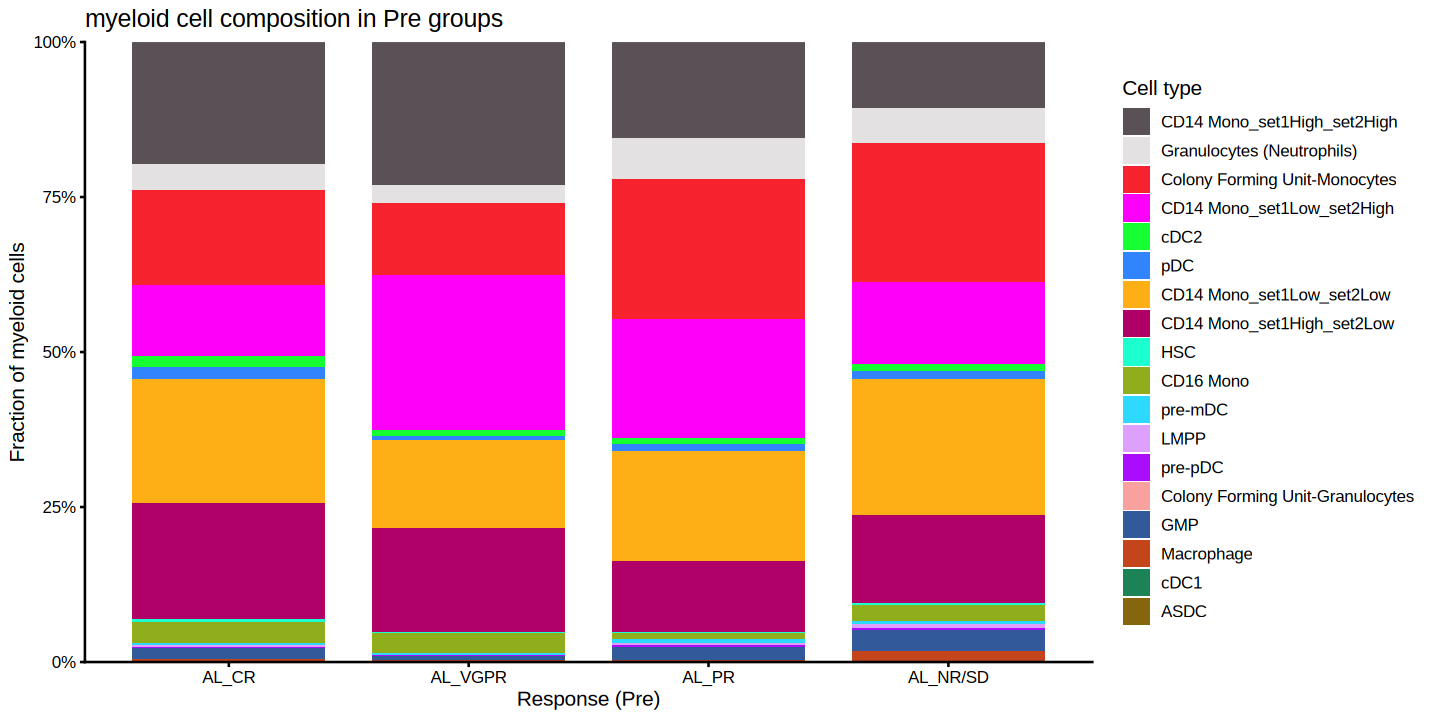

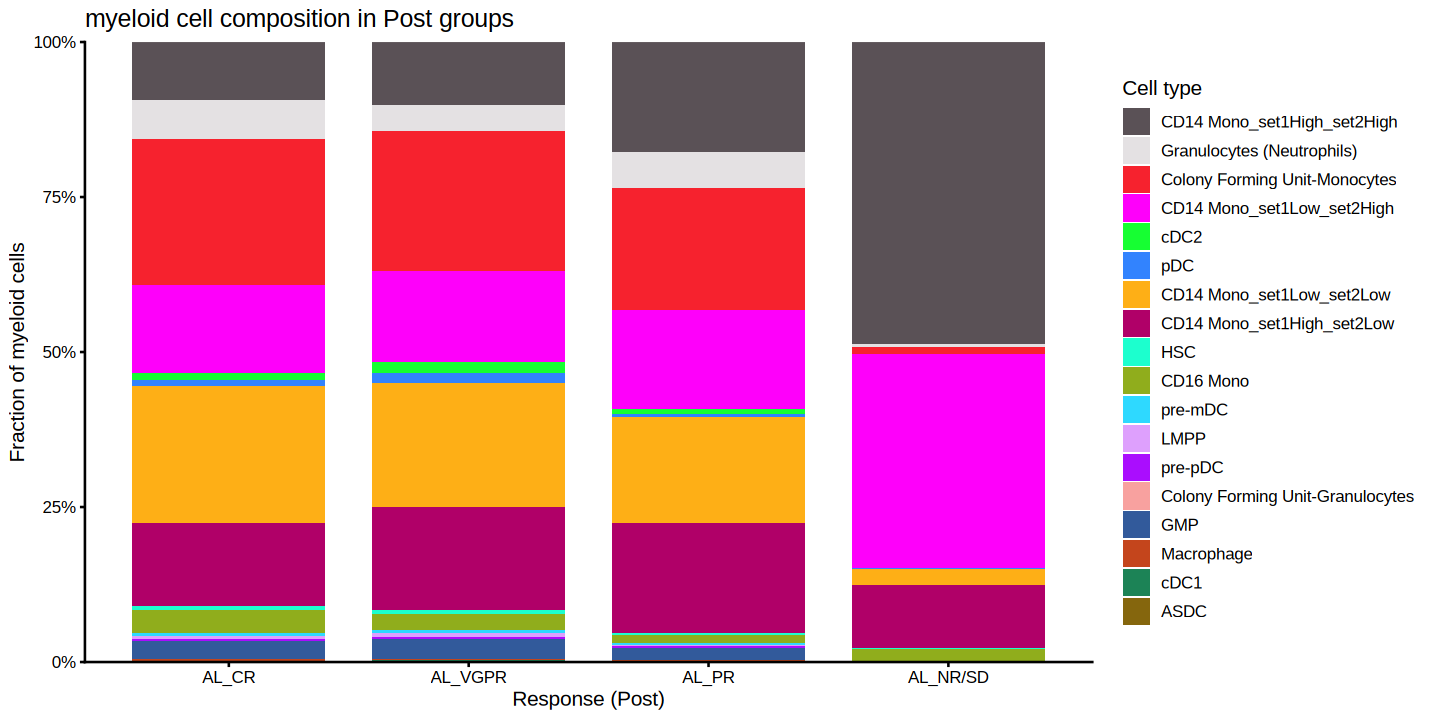

In [33]:
# --- Stacked bar plot for Pre groups ---
options(repr.plot.height = 6, repr.plot.width = 12)

comp$response <- factor(comp$response,
                        levels = c("AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD","Normal", "AL_NotRecorded"))

p_pre <- ggplot(
  comp %>%
    filter(treatment == "Pre",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre)", y = "Fraction of myeloid cells", fill = "Cell type",
       title = "myeloid cell composition in Pre groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- Stacked bar plot for Post groups ---
p_post <- ggplot(
  comp %>%
    filter(treatment == "Post",
           !response %in% c("Normal", "AL_NotRecorded")),
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post)", y = "Fraction of myeloid cells", fill = "Cell type",
       title = "myeloid cell composition in Post groups") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


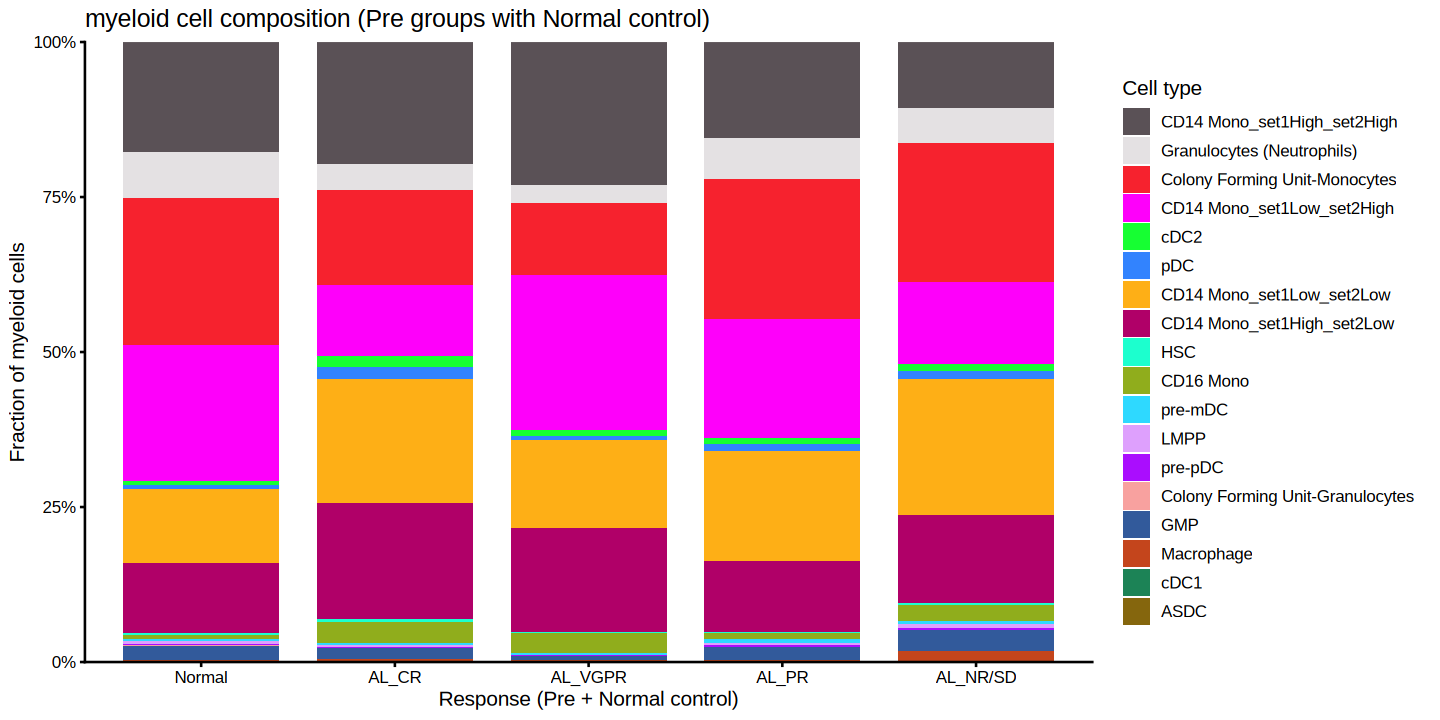

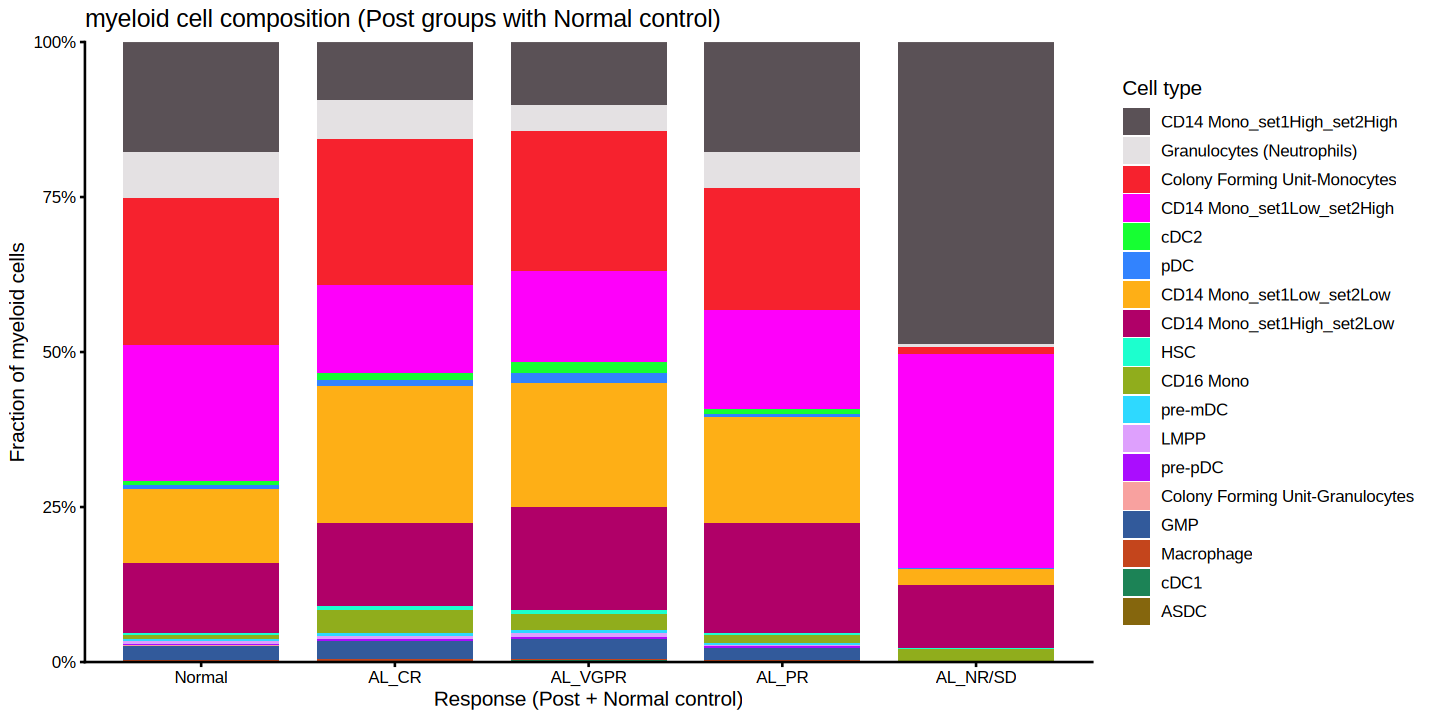

In [34]:
library(dplyr)
library(ggplot2)
library(scales)

# --- Ensure consistent response order ---
comp$response <- factor(
  comp$response,
  levels = c("Normal", "AL_NotRecorded", "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD")
)

# --- 1) Collapse Normal group (no treatment) ---
normal_bar <- comp %>%
  filter(response == "Normal") %>%
  group_by(celltype) %>%
  summarise(frac = mean(frac, na.rm = TRUE), .groups = "drop") %>%
  mutate(response = "Normal") %>%
  # Ensure Normal sums to 1 across celltypes
  mutate(frac = frac / sum(frac, na.rm = TRUE))

# --- 2) Pre dataset: keep only Pre rows + Normal bar ---
comp_pre_dat <- comp %>%
  filter(treatment == "Pre",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_pre_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_pre_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# --- 3) Post dataset: keep only Post rows + Normal bar ---
comp_post_dat <- comp %>%
  filter(treatment == "Post",
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  select(response, celltype, frac)

comp_post_dat <- bind_rows(
  normal_bar,    # Normal has no treatment
  comp_post_dat
) %>%
  # Normalize within each response so each stacked bar = 100%
  group_by(response) %>%
  mutate(frac = frac / sum(frac, na.rm = TRUE)) %>%
  ungroup()

# (Keep your plotting code unchanged)


# --- 4) Fix factor levels again ---
comp_pre_dat$response  <- factor(comp_pre_dat$response,  levels = levels(comp$response))
comp_post_dat$response <- factor(comp_post_dat$response, levels = levels(comp$response))

# --- 5) Stacked bar plot for Pre groups + Normal ---
options(repr.plot.height = 6, repr.plot.width = 12)

p_pre <- ggplot(
  comp_pre_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Pre + Normal control)", y = "Fraction of myeloid cells", fill = "Cell type",
       title = "myeloid cell composition (Pre groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_pre)

# --- 6) Stacked bar plot for Post groups + Normal ---
p_post <- ggplot(
  comp_post_dat,
  aes(x = response, y = frac, fill = celltype)
) +
  geom_col(position = "stack", width = 0.8) +
  scale_y_continuous(labels = percent_format(accuracy = 1), expand = c(0,0)) +
  scale_fill_manual(values = ct_cols) +
  labs(x = "Response (Post + Normal control)", y = "Fraction of myeloid cells", fill = "Cell type",
       title = "myeloid cell composition (Post groups with Normal control)") +
  theme_classic(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        legend.position = "right")

print(p_post)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <94>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warn

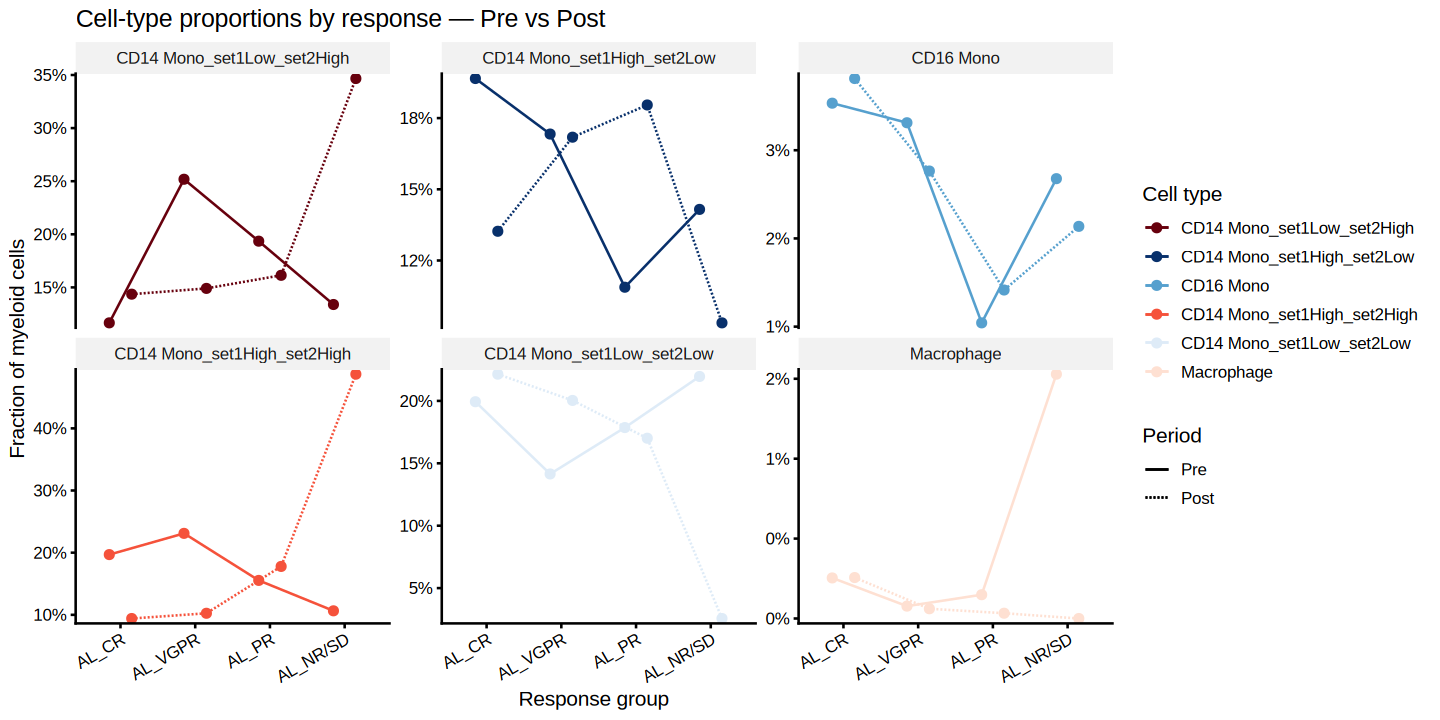

In [35]:
library(dplyr)
library(ggplot2)
library(scales)
library(RColorBrewer)


# ---------- SELECT WHICH CELL TYPES TO PLOT ----------
ct_focus <- c('CD14 Mono_set1Low_set2High','CD14 Mono_set1High_set2Low','CD16 Mono','CD14 Mono_set1High_set2High','CD14 Mono_set1Low_set2Low',  'Macrophage')

# --- 0) Keep only Pre/Post samples ---
comp_line <- comp %>%
  filter(treatment %in% c("Pre", "Post"),
         !response %in% c("Normal", "AL_NotRecorded")) %>%
  transmute(response = factor(response, levels = levels(comp$response)),
            celltype,
            frac,
            period = treatment)

# --- 0b) Subset by chosen cell types (if provided) ---
if (!is.null(ct_focus)) {
  comp_line <- comp_line %>% filter(celltype %in% ct_focus)
}

# --- 1) Consistent celltype order (overall mean, or keep ct_focus order if provided) ---
if (is.null(ct_focus)) {
  ct_levels <- comp_line %>%
    group_by(celltype) %>%
    summarise(m = mean(frac, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(m)) %>%
    pull(celltype)
} else {
  # preserve user-specified order
  ct_levels <- ct_focus
}
comp_line$celltype <- factor(comp_line$celltype, levels = ct_levels)

# --- 2) Red/Blue palette tuned to labels ---
n_ct   <- length(ct_levels)
is_red <- grepl("^Macrophage|CD14 Mono_set1Low_set2High|CD14 Mono_set1High_set2High", ct_levels)

n_red  <- sum(is_red)
n_blue <- n_ct - n_red

# darker → lighter ramps (avoid white center)
red_pal  <- colorRampPalette(RColorBrewer::brewer.pal(9, "Reds")[c(9,8,7,6,5,4,3,2)])
blue_pal <- colorRampPalette(RColorBrewer::brewer.pal(9, "Blues")[c(9,8,7,6,5,4,3,2)])

reds  <- if (n_red  > 0) red_pal(n_red)   else character(0)
blues <- if (n_blue > 0) blue_pal(n_blue) else character(0)

# assign: CD14 Mono* -> reds; others -> blues
col_vec <- character(n_ct)
col_vec[is_red]  <- reds
col_vec[!is_red] <- blues
names(col_vec)   <- ct_levels


# --- 3) Ensure Pre comes before Post ---
comp_line$period <- factor(comp_line$period, levels = c("Pre", "Post"))

# --- 4) Summarize mean and SE for error bars ---
summary_dat <- comp_line %>%
  group_by(celltype, response, period) %>%
  summarise(
    mean_frac = mean(frac, na.rm = TRUE),
    se_frac   = sd(frac, na.rm = TRUE) / sqrt(dplyr::n()),
    .groups = "drop"
  )

# --- 5) Line plot with red/blue palette ---
p_line <- ggplot(summary_dat, aes(x = response, y = mean_frac,
                                  color = celltype, group = period, linetype = period)) +
  geom_line(position = position_dodge(width = 0.6)) +
  geom_point(position = position_dodge(width = 0.6), size = 2) +
  geom_errorbar(aes(ymin = mean_frac - se_frac, ymax = mean_frac + se_frac),
                width = 0.2, position = position_dodge(width = 0.6)) +
  facet_wrap(~ celltype, ncol = 3, scales = "free_y") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1), expand = c(0.02, 0)) +
  scale_color_manual(values = col_vec) +
  labs(
    x = "Response group",
    y = "Fraction of myeloid cells",
    color = "Cell type",
    linetype = "Period",
    title = "Cell-type proportions by response — Pre vs Post"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "grey95", color = NA),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

print(p_line)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <94>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warn

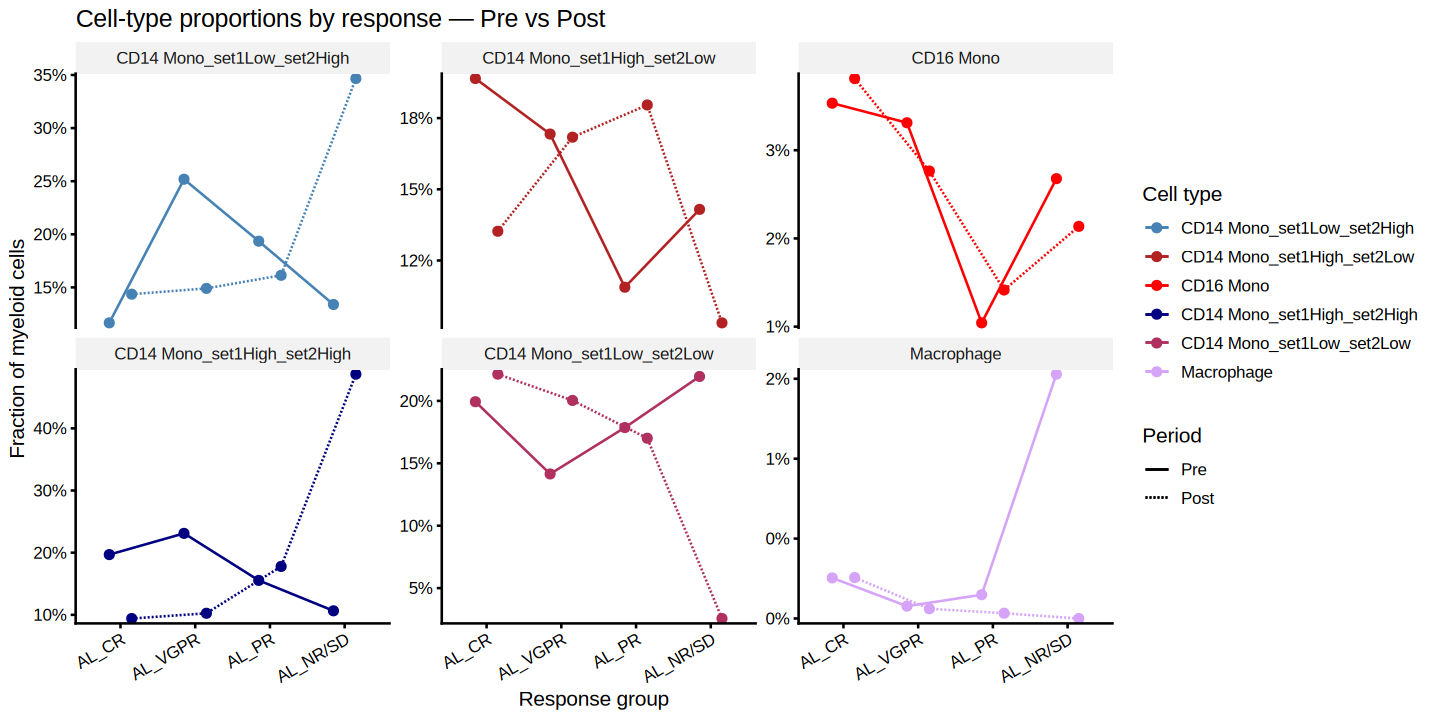

In [36]:
library(dplyr)
library(ggplot2)
library(scales)
library(RColorBrewer)

# ---------- SELECT WHICH CELL TYPES TO PLOT ----------
ct_focus <- c(
  'CD14 Mono_set1Low_set2High',
  'CD14 Mono_set1High_set2Low',
  'CD16 Mono',
  'CD14 Mono_set1High_set2High',
  'CD14 Mono_set1Low_set2Low',
  'Macrophage'
)

# ---------- MANUAL COLORS (edit these as you like) ----------
# names must EXACTLY match the celltype strings in your data
celltype_colors <- c(
  'CD14 Mono_set1Low_set2High'  = "steelblue",
  'CD14 Mono_set1High_set2Low'  = "firebrick",
  'CD14 Mono_set1High_set2High' = "navy",
  'CD14 Mono_set1Low_set2Low'   = "maroon",
  'CD16 Mono'                   = "red",
  'Macrophage'                  = "#D5A3F7"
)


# c("navy", "steelblue", "firebrick", "red")

# --- 0) Keep only Pre/Post samples ---
comp_line <- comp %>%
  filter(
    treatment %in% c("Pre", "Post"),
    !response %in% c("Normal", "AL_NotRecorded")
  ) %>%
  transmute(
    response = factor(response, levels = levels(comp$response)),
    celltype,
    frac,
    period = treatment
  )

# --- 0b) Subset by chosen cell types (if provided) ---
if (!is.null(ct_focus)) {
  comp_line <- comp_line %>% filter(celltype %in% ct_focus)
}

# --- 1) Consistent celltype order (overall mean, or keep ct_focus order if provided) ---
if (is.null(ct_focus)) {
  ct_levels <- comp_line %>%
    group_by(celltype) %>%
    summarise(m = mean(frac, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(m)) %>%
    pull(celltype)
} else {
  ct_levels <- ct_focus
}
comp_line$celltype <- factor(comp_line$celltype, levels = ct_levels)

# --- 2) Build color vector in the exact plotting order, with checks ---
missing_cols <- setdiff(ct_levels, names(celltype_colors))
if (length(missing_cols) > 0) {
  stop(
    "Missing manual colors for these celltypes:\n  - ",
    paste(missing_cols, collapse = "\n  - "),
    "\n\nAdd them to `celltype_colors` (names must match exactly)."
  )
}

# col_vec must be named with ALL levels you will plot
col_vec <- celltype_colors[ct_levels]
names(col_vec) <- ct_levels

# --- 3) Ensure Pre comes before Post ---
comp_line$period <- factor(comp_line$period, levels = c("Pre", "Post"))

# --- 4) Summarize mean and SE for error bars ---
summary_dat <- comp_line %>%
  group_by(celltype, response, period) %>%
  summarise(
    mean_frac = mean(frac, na.rm = TRUE),
    se_frac   = sd(frac, na.rm = TRUE) / sqrt(dplyr::n()),
    .groups   = "drop"
  )

# --- 5) Line plot with manual palette ---
p_line <- ggplot(
  summary_dat,
  aes(
    x = response, y = mean_frac,
    color = celltype, group = period, linetype = period
  )
) +
  geom_line(position = position_dodge(width = 0.6)) +
  geom_point(position = position_dodge(width = 0.6), size = 2) +
  geom_errorbar(
    aes(ymin = mean_frac - se_frac, ymax = mean_frac + se_frac),
    width = 0.2, position = position_dodge(width = 0.6)
  ) +
  facet_wrap(~ celltype, ncol = 3, scales = "free_y") +
  scale_y_continuous(
    labels = scales::percent_format(accuracy = 1),
    expand = c(0.02, 0)
  ) +
  scale_color_manual(values = col_vec, breaks = ct_levels, drop = FALSE) +
  labs(
    x = "Response group",
    y = "Fraction of myeloid cells",
    color = "Cell type",
    linetype = "Period",
    title = "Cell-type proportions by response — Pre vs Post"
  ) +
  theme_classic(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "grey95", color = NA),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

print(p_line)


In [37]:
ggsave("Fig5B.pdf", plot = p_line, width = 9, height =6)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <94>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Cell-type proportions by response — Pre vs Post' in 'mbcsToSbcs': dot substituted for <80>"
Warn

## 10. Sample metadata and clinical groups


In [38]:
# 2) Define your targets (as a proper character vector)
targets <- c("CD14 Mono","CD16 Mono","ASDC","cDC1","cDC2",'Macrophage',"pDC","pre-mDC","pre-pDC")

Idents(bm_anno_myeloid)<-'final_label'

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno_myeloid))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
sce1_monodc <- subset(bm_anno_myeloid, idents = keep)


In [39]:
# 0) Clean labels and derive response/treatment per cell (anchored)
sce1_monodc$label <- as.character(sce1_monodc$label)
sce1_monodc$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_monodc$label)

meta_df <- sce1_monodc@meta.data %>%
  as.data.frame() %>%
  mutate(
    label_clean = gsub("[[:space:]'‘’\"“”]", "", label),
    response  = sub("_(pre|post)$", "", label_clean, perl = TRUE),
    treatment = case_when(
      grepl("(_pre)$",  label_clean, perl = TRUE) ~ "Pre",
      grepl("(_post)$", label_clean, perl = TRUE) ~ "Post",
      TRUE ~ NA_character_
    ),
    celltype  = Annotation
  )


# Attach for convenience
sce1_monodc$response  <- meta_df$response
sce1_monodc$treatment <- meta_df$treatment


pdf 
  2

Saved PDF: myeloid_DC_dotplot_nonsplit.pdf



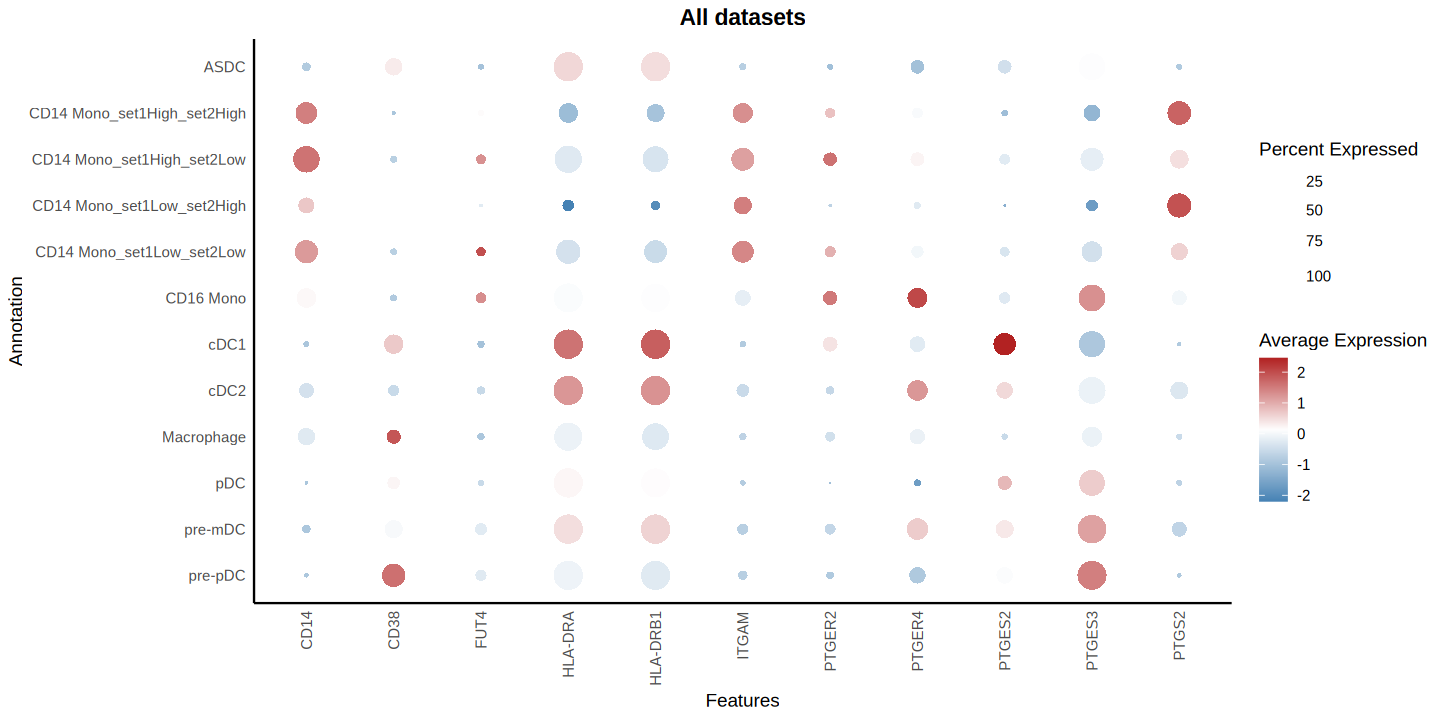

In [40]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(reshape2)
library(pheatmap)
library(RColorBrewer)
library(patchwork)

# ============================================================
# 1) Define targets
# ============================================================

targets <- c(
  "CD14 Mono", "CD16 Mono", "ASDC", "cDC1", "cDC2",
  "Macrophage", "pDC", "pre-mDC", "pre-pDC"
)

# Alphabetical target order
targets <- sort(unique(targets))

Idents(bm_anno_myeloid) <- "final_label"

available <- levels(Idents(bm_anno_myeloid))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in final_label.\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message(
    "These requested identities were NOT found and will be skipped: ",
    paste(missing, collapse = ", ")
  )
}

# ============================================================
# 2) Subset target myeloid/DC cells from original object
# ============================================================

sce1_monodc <- subset(bm_anno_myeloid, idents = keep)

# Keep response/treatment labels available after recreating sce1_monodc.
# These labels should be inherited from bm_anno_myeloid; derive from label as a fallback.
if (!all(c("response", "treatment") %in% colnames(sce1_monodc@meta.data))) {
  sce1_monodc$label <- as.character(sce1_monodc$label)
  sce1_monodc$label <- gsub("[[:space:]'‘’\"“”]", "", sce1_monodc$label)
  label_clean <- sce1_monodc$label
  
  sce1_monodc$response <- ifelse(
    grepl("_(pre|post)$", label_clean, perl = TRUE),
    sub("_(pre|post)$", "", label_clean, perl = TRUE),
    label_clean
  )
  
  sce1_monodc$treatment <- dplyr::case_when(
    grepl("_pre$",  label_clean, perl = TRUE) ~ "Pre",
    grepl("_post$", label_clean, perl = TRUE) ~ "Post",
    TRUE ~ NA_character_
  )
}

stopifnot(all(c("response", "treatment") %in% colnames(sce1_monodc@meta.data)))


# ============================================================
# 3) Define genes
# ============================================================

allgene <- c(
  "CD38", "ITGAM", "CD14", "FUT4", "HLA-DRA", "HLA-DRB1",
  "PTGS2", "PTGER2", "PTGER4", "PTGES2", "PTGES3"
)

# Alphabetical gene order
allgene <- sort(unique(allgene))

# Optional: keep only genes present in object
genes_found <- allgene[allgene %in% rownames(sce1_monodc)]
genes_missing <- setdiff(allgene, genes_found)

if (length(genes_missing) > 0) {
  message(
    "These requested genes were NOT found and will be skipped: ",
    paste(genes_missing, collapse = ", ")
  )
}

if (length(genes_found) == 0) {
  stop("None of the requested genes are present in the object.")
}

allgene <- genes_found

cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

blue_red_palette <- function(n) {
  colorRampPalette(c("steelblue", "white", "firebrick"))(n)
}

# ============================================================
# 4) Function to make DotPlot
#    - dataset_use = NULL gives non-split plot using all cells
#    - dataset_use = dataset name gives one split plot
# ============================================================

make_annotation_dotplot <- function(obj, dataset_use = NULL, plot_title = NULL) {
  
  if (!is.null(dataset_use)) {
    obj_sub <- subset(obj, subset = response == dataset_use)
  } else {
    obj_sub <- obj
  }
  
  if (ncol(obj_sub) == 0) {
    return(NULL)
  }
  
  Idents(obj_sub) <- "Annotation"
  
  if (length(unique(as.character(Idents(obj_sub)))) < 1) {
    return(NULL)
  }
  
  initial_plot <- DotPlot(
    obj_sub,
    features = allgene,
    scale = TRUE,
    cols = cols_vec
  )
  
  plot_data <- initial_plot$data
  
  # Alphabetical feature order
  plot_data$features.plot <- factor(
    plot_data$features.plot,
    levels = allgene
  )
  
  # Alphabetical Annotation order
  # rev(sort()) displays A-to-Z from top to bottom on ggplot y-axis
  annotation_order <- rev(sort(unique(as.character(plot_data$id))))
  
  plot_data$id <- factor(
    plot_data$id,
    levels = annotation_order
  )
  
  if (is.null(plot_title)) {
    plot_title <- ifelse(is.null(dataset_use), "All datasets", dataset_use)
  }
  
  p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
    geom_point(
      aes(size = pct.exp, fill = avg.exp.scaled),
      shape = 21,
      color = "black",
      stroke = 0
    ) +
    scale_size(range = c(0, 8), name = "Percent Expressed") +
    scale_fill_gradientn(
      colors = blue_red_palette(100),
      name = "Average Expression"
    ) +
    scale_x_discrete(limits = allgene) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.background = element_blank(),
      axis.line = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5, face = "bold")
    ) +
    labs(
      title = plot_title,
      x = "Features",
      y = "Annotation"
    )
  
  return(p)
}

# ============================================================
# 5) Generate non-split and split plots
# ============================================================

# Non-split plot: all datasets pooled
p_all <- make_annotation_dotplot(
  sce1_monodc,
  dataset_use = NULL,
  plot_title = "All datasets"
)

# ============================================================
# 6) Save non-split and split plots to the same PDF
# ============================================================

out_pdf <- "myeloid_DC_dotplot_nonsplit.pdf"

pdf(out_pdf, width = 6, height =6)

# Page 1: non-split / pooled plot
print(p_all)


dev.off()

message("Saved PDF: ", out_pdf)

# Show in notebook/RStudio
p_all

## 11. Gene-expression program analysis


Built signatures:

  [metaGEP1] genes=50 (requested 50)

  [metaGEP2] genes=50 (requested 50)

  [metaGEP3] genes=50 (requested 50)

  [metaGEP4] genes=50 (requested 50)

[metaGEP1] present: 50/50

[metaGEP2] present: 50/50

[metaGEP3] present: 50/50

[metaGEP4] present: 50/50

Signature score columns added: Sig_metaGEP1, Sig_metaGEP2, Sig_metaGEP3, Sig_metaGEP4

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



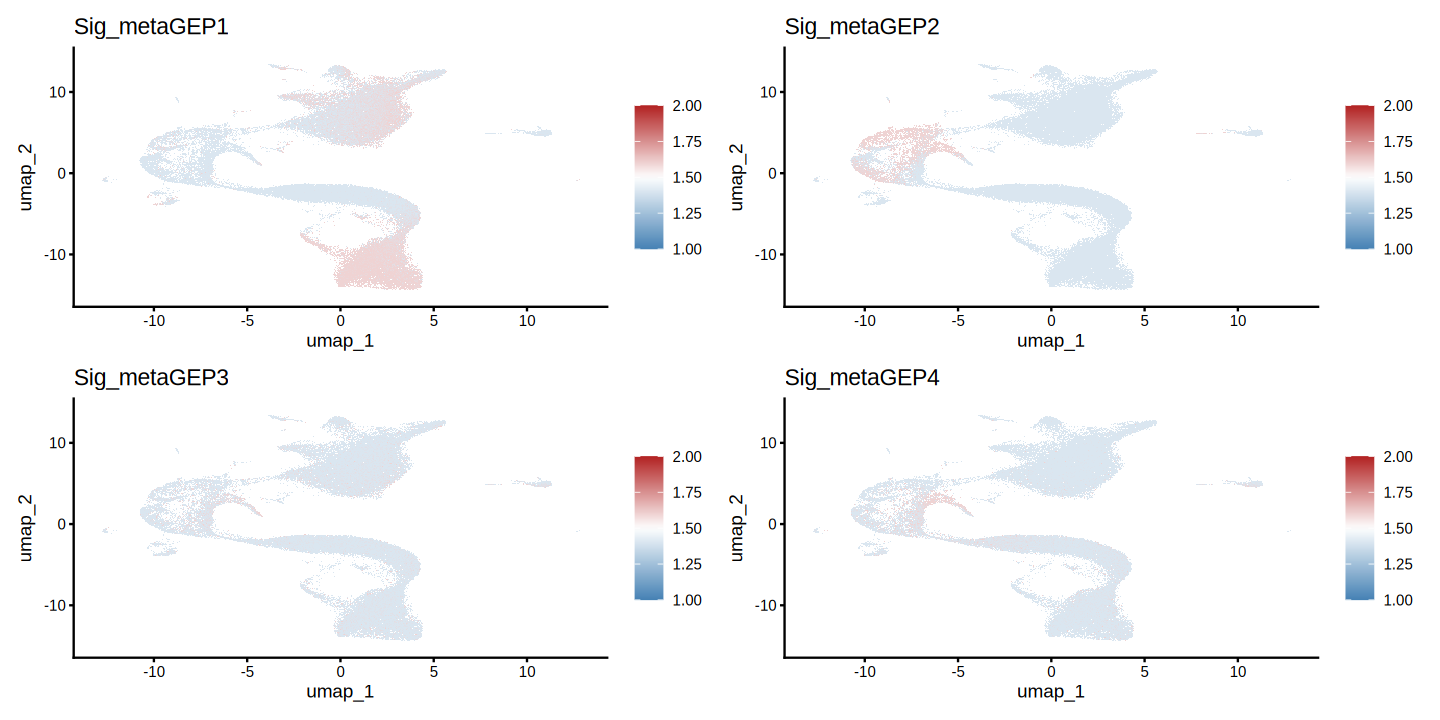

In [41]:
gep_df<-read.csv(file='HSC_old_signature.csv')
colnames(gep_df)<-gsub('Symbol','symbol',colnames(gep_df))
colnames(gep_df)<-gsub('metaGEP.','metaGEP:',colnames(gep_df))
# ============================================================
# metaGEP Top-100 signatures -> ModuleScore -> UMAP + cluster plots
#   Inputs:
#     1) Seurat object: `all` (or set OBJ_NAME below)
#     2) Table 3 data.frame: `gep_df` with columns:
#          symbol, metaGEP:1, metaGEP:2, metaGEP:3, metaGEP:4
#        (If loading from CSV, keep check.names=FALSE so colons survive.)
#   Outputs:
#     - Adds meta.data columns: Sig_metaGEP1..Sig_metaGEP4
#     - UMAP FeaturePlots for each signature score
#     - Violin plots of signature scores by Seurat clusters
#     - Average score heatmap-like dotplot by clusters
# ============================================================
# ----------------------------
# USER SETTINGS
# ----------------------------
obj <- bm_anno_myeloid                              # <- your Seurat object
umap_reduction <- "umap"    # <- change if your UMAP reduction name differs
cluster_col <- "Annotation"         # <- change if you use another clustering column
assay_use <- DefaultAssay(obj)

TOP_N <- 50
USE_POSITIVE_ONLY <- TRUE                # recommended for "contribution Z-scores"
MIN_GENES_PRESENT <- 2                   # safeguard for AddModuleScore
module_name_prefix <- "GEP_"             # temporary AddModuleScore prefix

# ----------------------------
# OPTIONAL: Load Table 3 if needed
# ----------------------------
# gep_df <- read.csv("Table3_metaGEP_zscores.csv", check.names = FALSE)
# stopifnot(all(c("symbol","metaGEP:1","metaGEP:2","metaGEP:3","metaGEP:4") %in% colnames(gep_df)))

stopifnot("symbol" %in% colnames(gep_df))

# ----------------------------
# 1) Build Top-100 signatures per metaGEP
# ----------------------------
gep_cols <- grep("^metaGEP:", colnames(gep_df), value = TRUE)
if (length(gep_cols) == 0) stop("No columns starting with 'metaGEP:' found in gep_df.")

topN_for_gep <- function(df, col, n = 100, positive_only = TRUE) {
  x <- df %>%
    select(symbol, Z = all_of(col)) %>%
    filter(!is.na(symbol), symbol != "", !is.na(Z))
  if (positive_only) x <- x %>% filter(Z > 0)
  x %>%
    arrange(desc(Z)) %>%
    slice_head(n = n) %>%
    pull(symbol) %>%
    unique()
}

ct_sigs <- setNames(
  lapply(gep_cols, function(gc) topN_for_gep(gep_df, gc, n = TOP_N, positive_only = USE_POSITIVE_ONLY)),
  nm = paste0("metaGEP", sub("^metaGEP:", "", gep_cols))  # metaGEP1..4
)

message("Built signatures:")
for (nm in names(ct_sigs)) {
  message(sprintf("  [%s] genes=%d (requested %d)", nm, length(ct_sigs[[nm]]), TOP_N))
}

# ----------------------------
# 2) Case-insensitive matching to Seurat features
# ----------------------------
feat_all   <- rownames(obj[[assay_use]])
feat_upper <- toupper(feat_all)

ct_sigs_present <- lapply(names(ct_sigs), function(nm) {
  genes <- ct_sigs[[nm]]
  idx <- match(toupper(genes), feat_upper)
  present <- feat_all[idx[!is.na(idx)]]
  missing <- genes[is.na(idx)]
  message(sprintf("[%s] present: %d/%d", nm, length(present), length(genes)))
  if (length(missing) > 0) message(sprintf("[%s] missing (showing up to 30): %s",
                                          nm, paste(head(missing, 30), collapse = ", ")))
  present
})
names(ct_sigs_present) <- names(ct_sigs)

# Drop low-coverage signatures
keep <- vapply(ct_sigs_present, length, integer(1)) >= MIN_GENES_PRESENT
if (!all(keep)) {
  message("Dropping low-coverage signatures: ", paste(names(ct_sigs_present)[!keep], collapse = ", "))
  ct_sigs_present <- ct_sigs_present[keep]
}
if (length(ct_sigs_present) == 0) stop("No signatures have enough genes present to score.")

# ----------------------------
# 3) Add module scores
# ----------------------------
obj <- AddModuleScore(
  object   = obj,
  features = unname(ct_sigs_present),
  assay    = assay_use,
  name     = module_name_prefix
)

# AddModuleScore makes columns like GEP_1, GEP_2, ...
new_cols <- grep(paste0("^", module_name_prefix, "\\d+$"), colnames(obj[[]]), value = TRUE)
stopifnot(length(new_cols) == length(ct_sigs_present))

pretty_cols <- paste0("Sig_", names(ct_sigs_present))
for (i in seq_along(new_cols)) {
  obj[[pretty_cols[i]]] <- obj[[new_cols[i]]][, 1]
}

sig_features <- pretty_cols
message("Signature score columns added: ", paste(sig_features, collapse = ", "))

# ----------------------------
# 4) Visualization: Signature scores on UMAP
# ----------------------------
# Color palette (same style you used)
blue_yellow_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))
cols_vec <- blue_yellow_palette(26)

# Validate reduction exists
if (!(umap_reduction %in% Reductions(obj))) {
  stop(sprintf("Reduction '%s' not found. Available: %s",
               umap_reduction, paste(Reductions(obj), collapse = ", ")))
}

p_umap <- lapply(sig_features, function(f) {
  FeaturePlot(
    object     = obj,
    features   = f,
    reduction  = umap_reduction,
    cols       = cols_vec,
    order      = TRUE,
    pt.size    = 0.2,
    min.cutoff = "q05",
    max.cutoff = "q95"
  ) +
    ggtitle(f) +
    theme_classic()
})

if (requireNamespace("patchwork", quietly = TRUE)) {
  suppressPackageStartupMessages(library(patchwork))
  print(wrap_plots(p_umap, ncol = 2))
} else {
  for (p in p_umap) print(p)
}

# ----------------------------
# 5) Visualization: Signature scores across Seurat clusters
#    A) Violin plots by cluster (one plot per signature)
# ----------------------------
if (!(cluster_col %in% colnames(obj[[]]))) {
  stop(sprintf("cluster_col '%s' not found in meta.data. Available columns include: %s",
               cluster_col, paste(head(colnames(obj[[]]), 30), collapse = ", ")))
}

Idents(obj) <- obj[[cluster_col]][, 1]

p_vln <- lapply(sig_features, function(f) {
  VlnPlot(
    object  = obj,
    features = f,
    group.by = cluster_col,
    pt.size  = 0
  ) +
    ggtitle(paste0(f, " by ", cluster_col)) +
    theme_classic() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
})

if (requireNamespace("patchwork", quietly = TRUE)) {
  suppressPackageStartupMessages(library(patchwork))
  print(wrap_plots(p_vln, ncol = 2))
} else {
  for (p in p_vln) print(p)
}

# ----------------------------
# 5B) Average score per cluster (heatmap-like dotplot)
#     - Uses Seurat DotPlot over meta.features (works because scores are meta.data)
# ----------------------------
# DotPlot expects "features" to be in assay by default; for meta.data vars, use FetchData + ggplot.
md <- obj@meta.data %>%
  mutate(.cluster = as.factor(.data[[cluster_col]])) %>%
  select(.cluster, all_of(sig_features)) %>%
  pivot_longer(cols = all_of(sig_features), names_to = "Signature", values_to = "Score")

avg_by_cluster <- md %>%
  group_by(.cluster, Signature) %>%
  summarise(
    avg = mean(Score, na.rm = TRUE),
    pct_hi = mean(Score > 0, na.rm = TRUE),  # % cells with positive score (optional)
    .groups = "drop"
  )

p_avg <- ggplot(avg_by_cluster, aes(x = Signature, y = .cluster)) +
  geom_point(aes(size = pct_hi, color = avg)) +
  scale_color_gradient2(low = "steelblue", mid = "white", high = "firebrick") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "right"
  ) +
  labs(
    title = paste0("metaGEP signature scores by ", cluster_col),
    x = "Signature",
    y = "Cluster",
    color = "Mean score",
    size = "Frac(score>0)"
  )

print(p_avg)

# ----------------------------
# 6) (Optional) Save signatures and plots
# ----------------------------
# Save signature gene lists to files
# dir.create("metaGEP_signatures_top100", showWarnings = FALSE)
# for (nm in names(ct_sigs)) {
#   write.table(ct_sigs[[nm]], file = file.path("metaGEP_signatures_top100", paste0(nm, "_top100.txt")),
#               row.names = FALSE, col.names = FALSE, quote = FALSE)
# }

# Save UMAP plots
# ggsave("metaGEP_signature_scores_UMAP.pdf", wrap_plots(p_umap, ncol = 2), width = 12, height = 10)

# Save violin plots
# ggsave("metaGEP_signature_scores_Vln.pdf", wrap_plots(p_vln, ncol = 2), width = 12, height = 10)

# ----------------------------
# DONE
# obj now contains Sig_metaGEP* score columns in meta.data
# ----------------------------
obj

celltype,median_score,mean_score,n
<chr>,<dbl>,<dbl>,<int>
CD14 Mono_set1High_set2High,0.64899151,0.63193138,24382
CD14 Mono_set1Low_set2High,0.61727351,0.58518320,22054
CD14 Mono_set1High_set2Low,0.44755711,0.44263477,22054
CD16 Mono,0.39772822,0.41484706,3700
cDC2,0.33458918,0.33231229,1580
CD14 Mono_set1Low_set2Low,0.31998893,0.32591657,24382
HSC,0.28160071,0.27395718,329
pre-mDC,0.19950239,0.21506303,351
cDC1,0.14450570,0.17615596,174


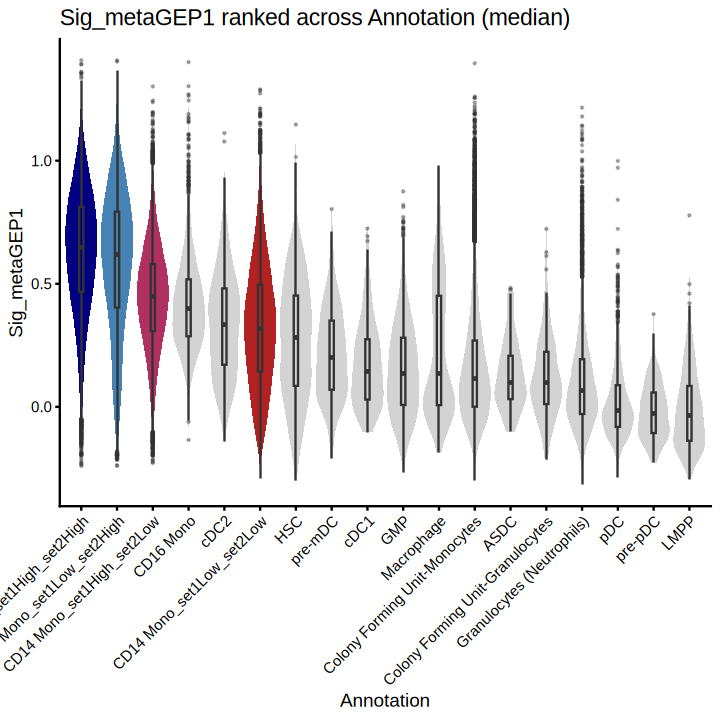

In [42]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(ggplot2)
  library(forcats)
})

# ----------------------------
# SETTINGS
# ----------------------------
obj         <- obj
celltype_col<- "Annotation"      # cell subtypes to rank
score_col   <- "Sig_metaGEP1"    # metaGEP1 module score column in meta.data

stopifnot(celltype_col %in% colnames(obj[[]]))
stopifnot(score_col    %in% colnames(obj[[]]))

# ----------------------------
# 1) Build the SAME discrete color logic as your UMAP_tag plot
#    (CD14 Mono subtypes get navy/steelblue/firebrick/maroon; all others lightgrey)
# ----------------------------
all_labs    <- unique(obj[[celltype_col]][,1])
cd14_levels <- grep("^CD14 Mono", all_labs, value = TRUE)

base_panel  <- c("navy", "steelblue", "firebrick", "maroon")
cd14_cols   <- base_panel[seq_len(min(length(cd14_levels), length(base_panel)))]
if (length(cd14_levels) > length(cd14_cols)) {
  cd14_cols <- rep(base_panel, length.out = length(cd14_levels))
}

# Named palette matched by *cell subtype name*
pal_celltype <- setNames(rep("lightgrey", length(all_labs)), all_labs)
pal_celltype[cd14_levels] <- setNames(cd14_cols, cd14_levels)

# ----------------------------
# 2) Rank cell subtypes by metaGEP1 (median; switch to mean if you want)
# ----------------------------
md <- obj@meta.data %>%
  transmute(
    celltype = as.character(.data[[celltype_col]]),
    score    = .data[[score_col]]
  ) %>%
  filter(!is.na(celltype), !is.na(score))

rank_tbl <- md %>%
  group_by(celltype) %>%
  summarise(
    median_score = median(score, na.rm = TRUE),
    mean_score   = mean(score, na.rm = TRUE),
    n            = dplyr::n(),
    .groups = "drop"
  ) %>%
  arrange(desc(median_score))

md$celltype <- factor(md$celltype, levels = rank_tbl$celltype)

# ----------------------------
# 3) Violin plot (ranked) with matched-by-name colors
# ----------------------------
options(repr.plot.height = 6, repr.plot.width = 6)

p <- ggplot(md, aes(x = celltype, y = score, fill = celltype)) +
  geom_violin(scale = "width", trim = TRUE, color = NA) +
  geom_boxplot(width = 0.12, outlier.size = 0.2, alpha = 0.35) +
  scale_fill_manual(values = pal_celltype, drop = FALSE) +
  theme_classic() +
  theme(
    axis.text.x  = element_text(angle = 45, hjust = 1, vjust = 1),
    legend.position = "none"
  ) +
  labs(
    title = paste0(score_col, " ranked across ", celltype_col, " (median)"),
    x = celltype_col,
    y = score_col
  )

print(p)

# (Optional) See the ranking table
rank_tbl

In [43]:
# ----------------------------
# Save to PDF
# ----------------------------
out_file <- "Sig_metaGEP1_violin_ranked_by_celltype.pdf"

ggsave(
  filename = out_file,
  plot     = p,
  device   = "pdf",
  width    = 6,
  height   = 6,
  units    = "in",
  useDingbats = FALSE
)

message("Saved to: ", normalizePath(out_file))

# A tibble: 2 × 2
  ratio_bin     n
  <fct>     <int>
1 Ratio < 1    26
2 Ratio > 1    10

	Wilcoxon rank sum test with continuity correction

data:  mean_hsc_score by ratio_bin
W = 79, p-value = 0.07449
alternative hypothesis: true location shift is not equal to 0

# A tibble: 2 × 8
  ratio_bin n_patients median_num median_den median_ratio iqr_ratio
  <fct>          <int>      <dbl>      <dbl>        <dbl>     <dbl>
1 Ratio < 1         26       364       1116.        0.485     0.564
2 Ratio > 1         10      1836.       828         2.11      1.14 
# ℹ 2 more variables: median_hsc_score <dbl>, iqr_hsc_score <dbl>


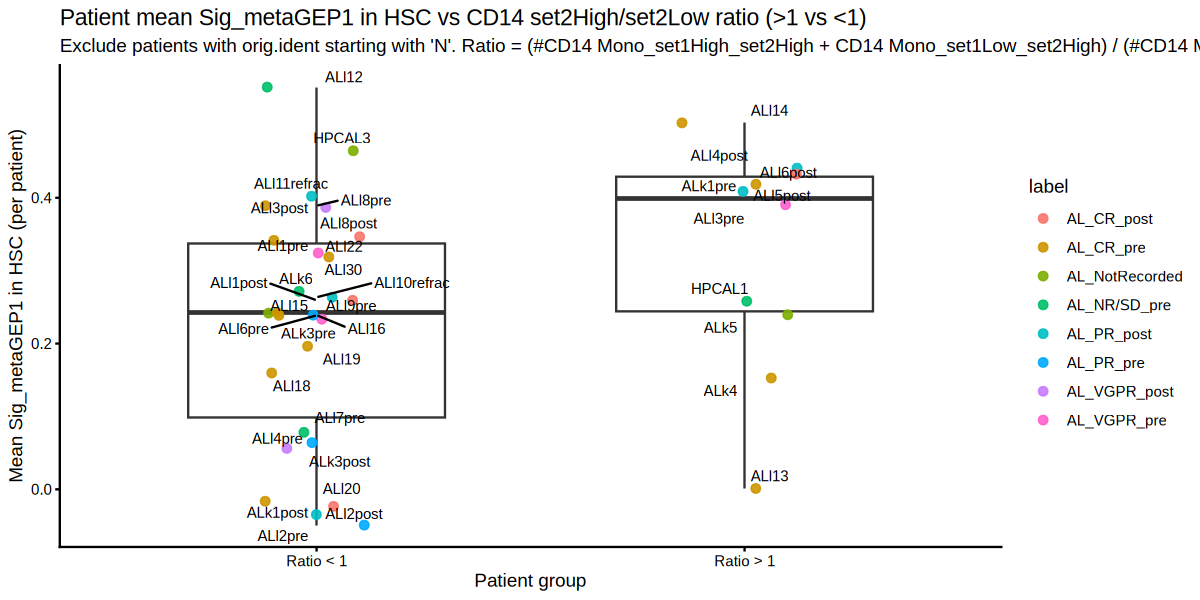

In [44]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
})

# ----------------------------
# SETTINGS
# ----------------------------
obj          <- obj
patient_col  <- "orig.ident"
celltype_col <- "Annotation"
score_col    <- "Sig_metaGEP1"

# Numerator: set2High (two subtypes)
cd14_num_types <- c("CD14 Mono_set1High_set2High", "CD14 Mono_set1Low_set2High")

# Denominator: set2Low (two subtypes)
cd14_den_types <- c("CD14 Mono_set1High_set2Low", "CD14 Mono_set1Low_set2Low")

ratio_label   <- "CD14 set2High / set2Low (counts)"
hsc_pattern   <- "HSC"

min_cells_num <- 1   # per patient numerator cells
min_cells_den <- 1   # per patient denominator cells
min_cells_hsc <- 1   # per patient HSC cells

# If denominator can be 0, pick one:
ratio_mode  <- "pseudocount"   # "pseudocount" | "filter_den0"
pseudocount <- 0.5             # used only if ratio_mode == "pseudocount"

# Optional: color points by a patient-level label column
use_label <- TRUE
label_col <- "label"  # <-- CHANGE to your metadata column name (e.g., "Condition", "group", "Responder")

label_patients <- TRUE
max_overlaps   <- 30

stopifnot(patient_col %in% colnames(obj[[]]))
stopifnot(celltype_col %in% colnames(obj[[]]))
stopifnot(score_col    %in% colnames(obj[[]]))
if (use_label) stopifnot(label_col %in% colnames(obj[[]]))

# ----------------------------
# 0) Build meta table ONCE (exclude patients that start with "N")
# ----------------------------
md <- obj@meta.data %>%
  transmute(
    patient  = as.character(.data[[patient_col]]),
    celltype = as.character(.data[[celltype_col]]),
    score    = .data[[score_col]],
    label    = if (use_label) as.character(.data[[label_col]]) else NA_character_
  ) %>%
  filter(!is.na(patient), !is.na(celltype), !is.na(score)) %>%
  filter(!grepl("^N", patient))   # <-- EXCLUDE orig.ident starting with "N"

# helper: patient-level mode label
mode_label <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  tab <- sort(table(x), decreasing = TRUE)
  names(tab)[1]
}

patient_label <- md %>%
  group_by(patient) %>%
  summarise(label = mode_label(label), .groups = "drop")

# ----------------------------
# 1) Compute numerator/denominator counts + ratio per patient
# ----------------------------
cd14_ratio_df <- md %>%
  filter(celltype %in% c(cd14_num_types, cd14_den_types)) %>%
  mutate(part = case_when(
    celltype %in% cd14_num_types ~ "num",
    celltype %in% cd14_den_types ~ "den",
    TRUE ~ NA_character_
  )) %>%
  count(patient, part, name = "n") %>%
  tidyr::pivot_wider(names_from = part, values_from = n, values_fill = 0) %>%
  transmute(
    patient,
    n_num = as.integer(num),
    n_den = as.integer(den)
  ) %>%
  filter(n_num >= min_cells_num)

if (ratio_mode == "filter_den0") {
  cd14_ratio_df <- cd14_ratio_df %>%
    filter(n_den >= min_cells_den) %>%
    mutate(ratio = n_num / n_den)
} else if (ratio_mode == "pseudocount") {
  cd14_ratio_df <- cd14_ratio_df %>%
    mutate(ratio = (n_num + pseudocount) / (n_den + pseudocount))
} else {
  stop("ratio_mode must be 'pseudocount' or 'filter_den0'")
}

# ----------------------------
# 1b) Bin by ratio >1 vs <1 (drop ==1)
# ----------------------------
cd14_ratio_df <- cd14_ratio_df %>%
  mutate(ratio_bin = case_when(
    ratio > 1 ~ "Ratio > 1",
    ratio < 1 ~ "Ratio < 1",
    TRUE      ~ "Ratio = 1"
  )) %>%
  filter(ratio_bin != "Ratio = 1") %>%
  mutate(ratio_bin = factor(ratio_bin, levels = c("Ratio < 1", "Ratio > 1")))

if (nrow(cd14_ratio_df) < 4) stop("Too few patients after ratio binning (>1 vs <1).")

# ----------------------------
# 2) HSC mean score per patient
# ----------------------------
hsc_by_patient <- md %>%
  filter(grepl(hsc_pattern, celltype)) %>%
  group_by(patient) %>%
  summarise(
    n_hsc = n(),
    mean_hsc_score = mean(score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n_hsc >= min_cells_hsc)

plot_df <- hsc_by_patient %>%
  inner_join(cd14_ratio_df, by = "patient")

if (use_label) {
  plot_df <- plot_df %>% left_join(patient_label, by = "patient")
}

if (nrow(plot_df) < 4) stop("Too few patients after joining ratio + HSC filters.")

# QC
print(plot_df %>% count(ratio_bin))

# ----------------------------
# 3) Stats (2 groups => Wilcoxon)
# ----------------------------
wt <- wilcox.test(mean_hsc_score ~ ratio_bin, data = plot_df, exact = FALSE)
print(wt)

# ----------------------------
# 4) Plot
# ----------------------------
options(repr.plot.height = 5, repr.plot.width = 10)

subtitle_txt <- paste0(
  "Exclude patients with orig.ident starting with 'N'. ",
  "Ratio = (#", paste(cd14_num_types, collapse = " + "), ") / (#", paste(cd14_den_types, collapse = " + "), "). ",
  "Filters: n_num>=", min_cells_num,
  ifelse(ratio_mode == "filter_den0", paste0(", n_den>=", min_cells_den),
         paste0(", pseudocount=", pseudocount, " (allows n_den=0)")),
  "; HSC mean per patient (n_hsc>=", min_cells_hsc, "). ",
  "Wilcoxon p=", signif(wt$p.value, 3)
)

p <- ggplot(plot_df, aes(x = ratio_bin, y = mean_hsc_score)) +
  geom_boxplot(outlier.shape = NA, width = 0.6) +
  {
    if (use_label) geom_jitter(aes(color = label), width = 0.15, height = 0, size = 2, alpha = 0.9)
    else          geom_jitter(width = 0.15, height = 0, size = 2, alpha = 0.9)
  } +
  theme_classic() +
  theme(legend.position = if (use_label) "right" else "none") +
  labs(
    title = paste0("Patient mean ", score_col, " in HSC vs CD14 set2High/set2Low ratio (>1 vs <1)"),
    subtitle = subtitle_txt,
    x = "Patient group",
    y = paste0("Mean ", score_col, " in HSC (per patient)"),
    color = if (use_label) label_col else NULL
  )

if (label_patients) {
  p <- p + ggrepel::geom_text_repel(aes(label = patient), size = 3, max.overlaps = max_overlaps)
}

print(p)

# ----------------------------
# 5) Summary table
# ----------------------------
summary_df <- plot_df %>%
  group_by(ratio_bin) %>%
  summarise(
    n_patients = n(),
    median_num = median(n_num),
    median_den = median(n_den),
    median_ratio = median(ratio),
    iqr_ratio = IQR(ratio),
    median_hsc_score = median(mean_hsc_score),
    iqr_hsc_score = IQR(mean_hsc_score),
    .groups = "drop"
  )

print(summary_df)

# A tibble: 3 × 2
  ratio_q     n
  <fct>   <int>
1 Q1         13
2 Q2         13
3 Q3         10

	Kruskal-Wallis rank sum test

data:  mean_hsc_score by ratio_q
Kruskal-Wallis chi-squared = 6.5723, df = 2, p-value = 0.0374


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  plot_df$mean_hsc_score and plot_df$ratio_q 

   Q1   Q2  
Q2 0.06 -   
Q3 0.06 0.31

P value adjustment method: BH 

	Spearman's rank correlation rho

data:  plot_df$ratio and plot_df$mean_hsc_score
S = 4954, p-value = 0.02984
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3624196 



<theme> List of 148
 $ line                            : <ggplot2::element_line>
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ lineend      : chr "butt"
  ..@ linejoin     : chr "round"
  ..@ arrow        : logi FALSE
  ..@ arrow.fill   : chr "black"
  ..@ inherit.blank: logi TRUE
 $ rect                            : <ggplot2::element_rect>
  ..@ fill         : chr "white"
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ linejoin     : chr "round"
  ..@ inherit.blank: logi TRUE
 $ text                            : <ggplot2::element_text>
  ..@ family       : chr ""
  ..@ face         : chr "plain"
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : chr "black"
  ..@ size         : num 11
  ..@ hjust        : num 0.5
  ..@ vjust        : num 0.5
  ..@ angle        : num 0
  ..@ lineheight   : num 0.9
  ..@ margin       : <ggplot2::margin> nu

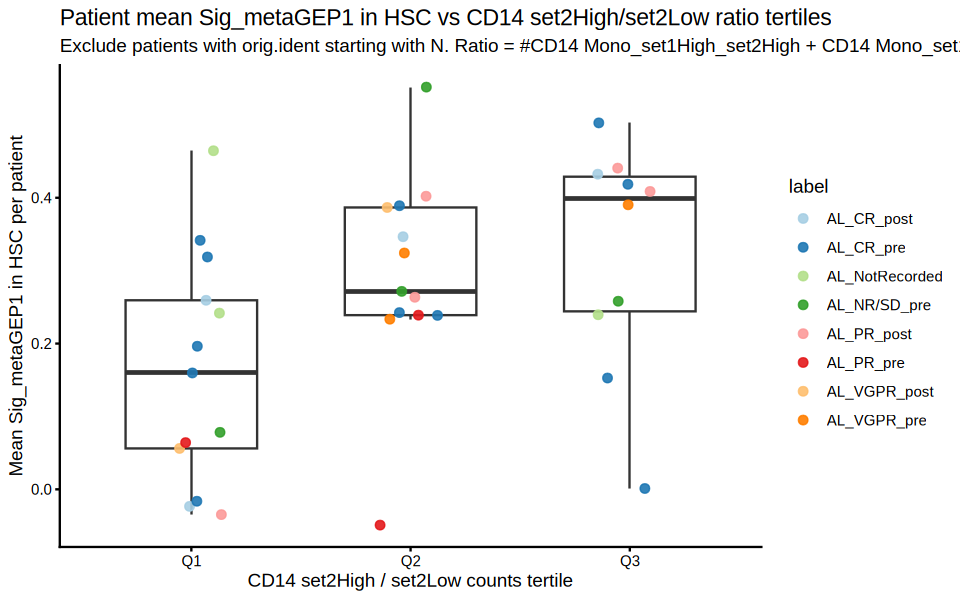

# A tibble: 3 × 8
  ratio_q n_patients median_num median_den median_ratio iqr_ratio
  <fct>        <int>      <dbl>      <dbl>        <dbl>     <dbl>
1 Q1              13       201        1053        0.162     0.123
2 Q2              13       993        1217        0.739     0.235
3 Q3              10      1836.        828        2.11      1.14 
# ℹ 2 more variables: median_hsc_score <dbl>, iqr_hsc_score <dbl>


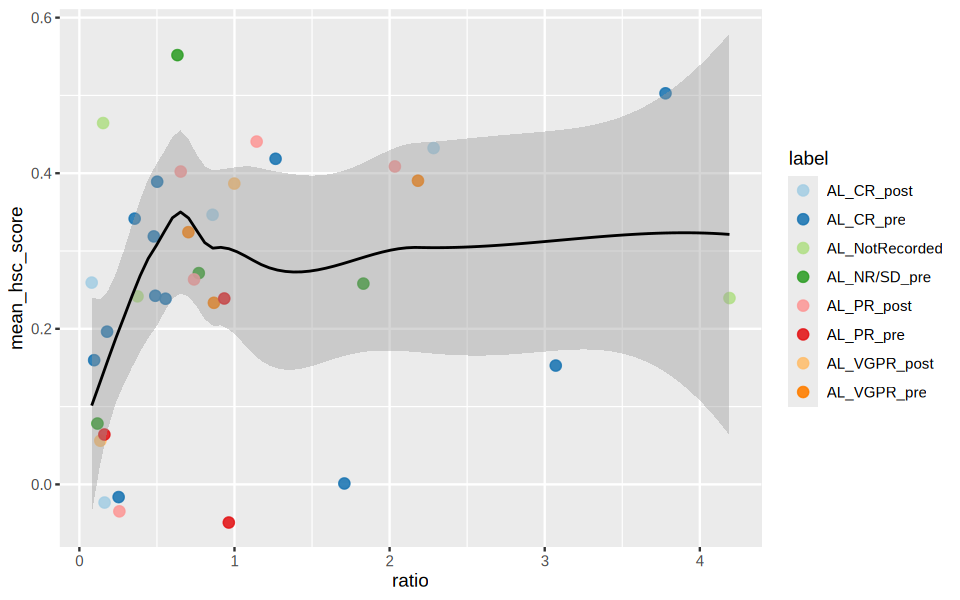

In [45]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(RColorBrewer)
})

# ----------------------------
# SETTINGS
# ----------------------------
obj          <- obj
patient_col  <- "orig.ident"
celltype_col <- "Annotation"
score_col    <- "Sig_metaGEP1"

# Numerator: set2High two subtypes
cd14_num_types <- c(
  "CD14 Mono_set1High_set2High",
  "CD14 Mono_set1Low_set2High"
)

# Denominator: set2Low two subtypes
cd14_den_types <- c(
  "CD14 Mono_set1High_set2Low",
  "CD14 Mono_set1Low_set2Low"
)

ratio_label   <- "CD14 set2High / set2Low counts"
hsc_pattern   <- "HSC"

min_cells_num <- 1
min_cells_den <- 1
min_cells_hsc <- 1

# If denominator can be 0, pick one:
ratio_mode  <- "pseudocount"  # "pseudocount" | "filter_den0"
pseudocount <- 0.5

# Optional: color points by patient-level label column
use_label <- TRUE
label_col <- "label"          # change if needed

# Text labels on scatter/boxplot
label_patients <- FALSE
max_overlaps   <- 30

# Output files
out_box_pdf     <- paste0(score_col, "_box.pdf")
out_scatter_pdf <- paste0(score_col, "_2D_scatter.pdf")
out_summary_csv <- paste0(score_col, "_summary_by_tertile.csv")
out_patient_csv <- paste0(score_col, "_patient_level_table.csv")

# ----------------------------
# Check columns
# ----------------------------
stopifnot(patient_col %in% colnames(obj[[]]))
stopifnot(celltype_col %in% colnames(obj[[]]))
stopifnot(score_col    %in% colnames(obj[[]]))

if (use_label) {
  stopifnot(label_col %in% colnames(obj[[]]))
}

# ----------------------------
# 0) Build metadata table
# Exclude patients starting with "N"
# ----------------------------
md <- obj@meta.data %>%
  transmute(
    patient  = as.character(.data[[patient_col]]),
    celltype = as.character(.data[[celltype_col]]),
    score    = .data[[score_col]],
    label    = if (use_label) as.character(.data[[label_col]]) else NA_character_
  ) %>%
  filter(!is.na(patient), !is.na(celltype), !is.na(score)) %>%
  filter(!grepl("^N", patient))

# ----------------------------
# Helper: patient-level mode label
# ----------------------------
mode_label <- function(x) {
  x <- x[!is.na(x)]
  if (length(x) == 0) return(NA_character_)
  tab <- sort(table(x), decreasing = TRUE)
  names(tab)[1]
}

patient_label <- md %>%
  group_by(patient) %>%
  summarise(
    label = mode_label(label),
    .groups = "drop"
  )

# ----------------------------
# 1) Compute numerator / denominator counts + ratio per patient
# ----------------------------
cd14_ratio_df <- md %>%
  filter(celltype %in% c(cd14_num_types, cd14_den_types)) %>%
  mutate(
    part = case_when(
      celltype %in% cd14_num_types ~ "num",
      celltype %in% cd14_den_types ~ "den",
      TRUE ~ NA_character_
    )
  ) %>%
  count(patient, part, name = "n") %>%
  tidyr::pivot_wider(
    names_from = part,
    values_from = n,
    values_fill = 0
  ) %>%
  mutate(
    num = ifelse(is.na(num), 0, num),
    den = ifelse(is.na(den), 0, den)
  ) %>%
  transmute(
    patient,
    n_num = as.integer(num),
    n_den = as.integer(den)
  ) %>%
  filter(n_num >= min_cells_num)

if (ratio_mode == "filter_den0") {
  cd14_ratio_df <- cd14_ratio_df %>%
    filter(n_den >= min_cells_den) %>%
    mutate(
      ratio = n_num / n_den
    )
} else if (ratio_mode == "pseudocount") {
  cd14_ratio_df <- cd14_ratio_df %>%
    mutate(
      ratio = (n_num + pseudocount) / (n_den + pseudocount)
    )
} else {
  stop("ratio_mode must be 'pseudocount' or 'filter_den0'")
}

if (nrow(cd14_ratio_df) < 6) {
  stop("Too few patients after ratio filtering to form 3 tertiles robustly. Need approximately >=6.")
}

# ----------------------------
# 2) Tertile calculation
# Q1 / Q2 / Q3 by ranked ratio
# ----------------------------
cd14_ratio_df <- cd14_ratio_df %>%
  arrange(ratio, patient) %>%
  mutate(
    ratio_q = dplyr::ntile(ratio, 3),
    ratio_q = factor(
      ratio_q,
      levels = 1:3,
      labels = paste0("Q", 1:3)
    )
  )

# ----------------------------
# 3) HSC mean score per patient
# ----------------------------
hsc_by_patient <- md %>%
  filter(grepl(hsc_pattern, celltype)) %>%
  group_by(patient) %>%
  summarise(
    n_hsc = n(),
    mean_hsc_score = mean(score, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n_hsc >= min_cells_hsc)

plot_df <- hsc_by_patient %>%
  inner_join(cd14_ratio_df, by = "patient")

if (use_label) {
  plot_df <- plot_df %>%
    left_join(patient_label, by = "patient") %>%
    mutate(label = factor(label))
}

if (nrow(plot_df) < 6) {
  stop("Too few patients after joining ratio + HSC filters.")
}

# ----------------------------
# QC: patients per tertile
# ----------------------------
qc_q <- plot_df %>%
  count(ratio_q) %>%
  tidyr::complete(ratio_q, fill = list(n = 0))

print(qc_q)

# ----------------------------
# 4) Statistics
# ----------------------------
kw <- kruskal.test(mean_hsc_score ~ ratio_q, data = plot_df)
print(kw)

pw <- pairwise.wilcox.test(
  x = plot_df$mean_hsc_score,
  g = plot_df$ratio_q,
  p.adjust.method = "BH",
  exact = FALSE
)
print(pw)

# Compact pairwise p-value text
pw_mat <- pw$p.value

pw_pairs <- tibble::tibble(
  comp = character(0),
  p_adj = numeric(0)
)

for (i in seq_len(nrow(pw_mat))) {
  for (j in seq_len(ncol(pw_mat))) {
    pv <- pw_mat[i, j]
    if (!is.na(pv)) {
      pw_pairs <- dplyr::bind_rows(
        pw_pairs,
        tibble::tibble(
          comp = paste0(colnames(pw_mat)[j], " vs ", rownames(pw_mat)[i]),
          p_adj = as.numeric(pv)
        )
      )
    }
  }
}

pw_text <- if (nrow(pw_pairs) == 0) {
  "Pairwise Wilcoxon BH: NA"
} else {
  paste0(
    "Pairwise Wilcoxon BH: ",
    paste0(
      pw_pairs$comp,
      " p=",
      signif(pw_pairs$p_adj, 3),
      collapse = " | "
    )
  )
}

# Optional correlation for 2D scatter
cor_test <- suppressWarnings(
  cor.test(
    plot_df$ratio,
    plot_df$mean_hsc_score,
    method = "spearman",
    exact = FALSE
  )
)

print(cor_test)

# ----------------------------
# 5) Subtitle
# ----------------------------
subtitle_txt <- paste0(
  "Exclude patients with orig.ident starting with N. ",
  "Ratio = #",
  paste(cd14_num_types, collapse = " + "),
  " / #",
  paste(cd14_den_types, collapse = " + "),
  ". Filters: n_num >= ",
  min_cells_num,
  ifelse(
    ratio_mode == "filter_den0",
    paste0(", n_den >= ", min_cells_den),
    paste0(", pseudocount = ", pseudocount, " allows n_den = 0")
  ),
  "; HSC mean per patient n_hsc >= ",
  min_cells_hsc,
  ". Kruskal-Wallis p = ",
  signif(kw$p.value, 3),
  ". ",
  pw_text
)

scatter_subtitle_txt <- paste0(
  "Each point is one patient. Color is the same as boxplot. ",
  "Spearman rho = ",
  signif(cor_test$estimate, 3),
  ", p = ",
  signif(cor_test$p.value, 3),
  ". Tertiles are retained in plot_df."
)

# ----------------------------
# 6A) Boxplot by tertile
# ----------------------------
options(repr.plot.height = 5, repr.plot.width = 8)

p_box <- ggplot(plot_df, aes(x = ratio_q, y = mean_hsc_score)) +
  geom_boxplot(
    outlier.shape = NA,
    width = 0.6
  ) +
  {
    if (use_label) {
      geom_jitter(
        aes(color = label),
        width = 0.15,
        height = 0,
        size = 2,
        alpha = 0.9
      )
    } else {
      geom_jitter(
        aes(color = ratio_q),
        width = 0.15,
        height = 0,
        size = 2,
        alpha = 0.9
      )
    }
  } +
  {
    if (use_label) {
      scale_color_brewer(palette = "Paired", drop = FALSE)
    } else {
      NULL
    }
  } +
  theme_classic() +
  theme(
    legend.position = if (use_label) "right" else "none"
  ) +
  labs(
    title = paste0(
      "Patient mean ",
      score_col,
      " in HSC vs CD14 set2High/set2Low ratio tertiles"
    ),
    subtitle = subtitle_txt,
    x = paste0(ratio_label, " tertile"),
    y = paste0("Mean ", score_col, " in HSC per patient"),
    color = if (use_label) label_col else NULL
  )

if (label_patients) {
  p_box <- p_box +
    ggrepel::geom_text_repel(
      aes(label = patient),
      size = 3,
      max.overlaps = max_overlaps
    )
}

print(p_box)

# ----------------------------
# 6B) 2D scatter plot
# x = continuous CD14 ratio
# y = HSC mean score
# color = same as boxplot
# ----------------------------
p_scatter <- ggplot(plot_df, aes(x = ratio, y = mean_hsc_score)) +
  {
    if (use_label) {
      geom_point(
        aes(color = label),
        size = 2.5,
        alpha = 0.9
      )
    } else {
      geom_point(
        aes(color = ratio_q),
        size = 2.5,
        alpha = 0.9
      )
    }
  } +
  {
    if (use_label) {
      scale_color_brewer(palette = "Paired", drop = FALSE)
    } else {
      NULL
    }
  } +
    geom_smooth(
      method = "loess",
      se = TRUE,
      color = "black",
      linewidth = 0.6,
      formula = y ~ x
    )
  theme_classic() +
  theme(
    legend.position = if (use_label) "right" else "none"
  ) +
  labs(
    title = paste0(
      "2D scatter: HSC ",
      score_col,
      " vs CD14 set2High/set2Low ratio"
    ),
    subtitle = scatter_subtitle_txt,
    x = ratio_label,
    y = paste0("Mean ", score_col, " in HSC per patient"),
    color = if (use_label) label_col else NULL
  )

if (label_patients) {
  p_scatter <- p_scatter +
    ggrepel::geom_text_repel(
      aes(label = patient),
      size = 3,
      max.overlaps = max_overlaps
    )
}

print(p_scatter)

# ----------------------------
# 7) Summary table
# ----------------------------
summary_df <- plot_df %>%
  group_by(ratio_q) %>%
  summarise(
    n_patients = n(),
    median_num = median(n_num),
    median_den = median(n_den),
    median_ratio = median(ratio),
    iqr_ratio = IQR(ratio),
    median_hsc_score = median(mean_hsc_score),
    iqr_hsc_score = IQR(mean_hsc_score),
    .groups = "drop"
  )

print(summary_df)

# ----------------------------
# 8) Save output tables
# ----------------------------
write.csv(
  summary_df,
  file = out_summary_csv,
  row.names = FALSE
)

write.csv(
  plot_df,
  file = out_patient_csv,
  row.names = FALSE
)

# ----------------------------
# 9) Save plots to separate PDFs
# ----------------------------
ggsave(
  filename = out_box_pdf,
  plot = p_box,
  device = "pdf",
  width = 10,
  height = 5,
  units = "in",
  useDingbats = FALSE
)

ggsave(
  filename = out_scatter_pdf,
  plot = p_scatter,
  device = "pdf",
  width = 10,
  height = 5,
  units = "in",
  useDingbats = FALSE
)

message("Saved boxplot to: ", normalizePath(out_box_pdf))
message("Saved scatter plot to: ", normalizePath(out_scatter_pdf))
message("Saved summary table to: ", normalizePath(out_summary_csv))
message("Saved patient-level table to: ", normalizePath(out_patient_csv))

## 12. Visualization and figure generation


In [46]:
sce1_monodc@meta.data$Annotation_grouped<-sce1_monodc@meta.data$Annotation
sce1_monodc@meta.data$Annotation_grouped<-gsub('CD14 Mono_set1Low_set2High','CD14 Mono set2High',sce1_monodc@meta.data$Annotation_grouped)
sce1_monodc@meta.data$Annotation_grouped<-gsub('CD14 Mono_set1High_set2High','CD14 Mono set2High',sce1_monodc@meta.data$Annotation_grouped)
sce1_monodc@meta.data$Annotation_grouped<-gsub('CD14 Mono_set1Low_set2Low','CD14 Mono set1High',sce1_monodc@meta.data$Annotation_grouped)
sce1_monodc@meta.data$Annotation_grouped<-gsub('CD14 Mono_set1High_set2Low','CD14 Mono set1High',sce1_monodc@meta.data$Annotation_grouped)
unique(sce1_monodc@meta.data$Annotation_grouped)

[1] "CD14 Mono set2High" "cDC2"               "pDC"               
 [4] "CD14 Mono set1High" "CD16 Mono"          "pre-mDC"           
 [7] "pre-pDC"            "Macrophage"         "cDC1"              
[10] "ASDC"

Calculating cluster CD14 Mono set2High

Calculating cluster cDC2

Calculating cluster pDC

Calculating cluster CD14 Mono set1High

Calculating cluster CD16 Mono

Calculating cluster pre-mDC

Calculating cluster pre-pDC

Calculating cluster Macrophage

Calculating cluster cDC1

Calculating cluster ASDC

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


png 
  3

Warning message in DoHeatmap(sce_small, features = features_for_heatmap, group.by = "Annotation_grouped", :
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: AUTS2, SEMA4C, FAM81A, FAM160A1, IGSF10, PROC, AL118508.1, PPM1J, CD200, PHYHD1, BEND6, KLF8, TET1, CCDC102A, RIBC2, NCAM1, CD5, TMEM121, PLS3, LTK, AL592430.1, GPR146, ADAM33, ATP1A2, B3GNT7, TLR3, HLA-DOB, BTLA, TSPAN15, BMERB1, RAMP1, PARM1, DPP4, ALOX15, MIR924HG, MRC2, TMEM14A, ZNF711, PHLDA3, GCSAM, BEND5, KCND3, SMO, ASB2, AC007993.3, COL4A4, EHF, IDO2, ENOX1, CGREF1, CYP2E1, FBXO27, SEPTIN3, CCDC74A, TMEM132E, ZNF462, ERICH5, TRIM47, FRMD4A, SLC16A10, CD163L1, OTOA, GATM, KCNJ5, FEZ1, SLC7A8, MRO, RAB42, KCNAB1, PIEZO2, HSD17B14, AC110995.1, SPIC, IGSF21, TMEM26, SDK2, EXO1, OIP5, KLHL23, RAD54L, DSCC1, HOXA7, ZNF730, SNHG31, NGFR, MELK, RDM1, E2F7, KIF18B, MS4A14, TNFRSF8, AC026369.3, SETBP1, CAMK1, SIDT2, FAM110A, RGS12, NSMF, PHF19, CDH23, LINC02432, SPRED1, CX3CR1, GP

ERROR: [1m[33mError[39m in `ggsave()`:[22m
[1m[22m[33m![39m Dimensions exceed 50 inches (`height` and `width` are specified in
  [3minches[23m not pixels).
[36mℹ[39m If you're sure you want a plot that big, use `limitsize = FALSE`.


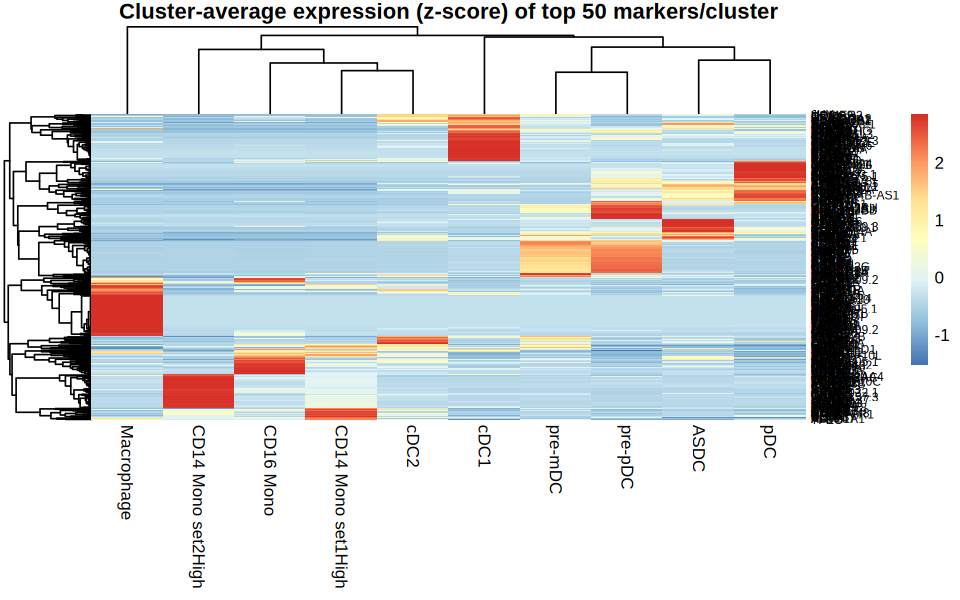

In [47]:
# ---- Packages ----
  library(Seurat)
  library(dplyr)
  library(tidyr)
  library(purrr)
  library(pheatmap)
  library(ggplot2)
# ---- Settings you can tweak ----
Idents(sce1_monodc) <- "Annotation_grouped"   # make sure clusters are the active identities
TOP_N <- 50                               # how many markers per cluster to keep
LOGFC_MIN <- 1                            # minimum avg_log2FC
PADJ_MAX <- 0.05                          # maximum adjusted p-value
DOWNSAMPLE_CELLS <- 100                   # cells per cluster for the cell-level heatmap (for readability)
OUT_DIR <- "markers_out_mono"

if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR)

# ---- 1) Find markers (positive only) ----
markers_all <- FindAllMarkers(
  sce1_monodc,
  only.pos = TRUE,              # positive markers
  test.use = "wilcox",          # default is fine; change if you prefer
  logfc.threshold = 0,          # we'll filter below to be explicit
  min.pct = 0.1
)

# Keep useful columns & filter
markers_filt <- markers_all %>%
  select(gene, cluster, p_val, avg_log2FC, pct.1, pct.2, p_val_adj) %>%
  filter(avg_log2FC >= LOGFC_MIN, p_val_adj <= PADJ_MAX)

# ---- 2) Top-N per cluster (by effect size) ----
top_markers <- markers_filt %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = TOP_N, with_ties = FALSE) %>%
  mutate(ramono = row_number()) %>%
  ungroup()

# Save a tidy long table of top markers (nice to read / sort)
write.csv(top_markers, file.path(OUT_DIR, sprintf("top%d_markers_long.csv", TOP_N)), row.names = FALSE)

# ---- 3) A wide "gene name table" (rows = ramono, columns = clusters) ----
# This is the quick visual list you asked for: each column is a cluster, each row one marker ramono.
gene_name_table <- top_markers %>%
  arrange(cluster, ramono) %>%
  select(cluster, ramono, gene) %>%
  pivot_wider(names_from = cluster, values_from = gene) %>%
  arrange(ramono)

write.csv(gene_name_table, file.path(OUT_DIR, sprintf("top%d_markers_genename_table_wide.csv", TOP_N)), row.names = FALSE)

# ---- 4) Heatmap: cluster-average expression of selected markers ----
# Pick unique genes across clusters
sel_genes <- unique(top_markers$gene)
sel_genes <- sel_genes[sel_genes %in% rownames(sce1_monodc)]  # keep only present genes

# Average expression by cluster (RNA/data slot: log-normalized recommended)
avg_mat <- AverageExpression(sce1_monodc, assays = "RNA", slot = "data", group.by = "Annotation_grouped")$RNA
avg_mat_sel <- avg_mat[intersect(sel_genes, rownames(avg_mat)), , drop = FALSE]

# Optional: row z-score for better contrast across clusters
row_zscore <- function(m) {
  t(scale(t(m)))
}
avg_mat_z <- row_zscore(as.matrix(avg_mat_sel))

# pheatmap (cluster-average)
png(file.path(OUT_DIR, sprintf("heatmap_cluster_avg_top%d.png", TOP_N)),
    width = 1600, height = 200 + 15 * nrow(avg_mat_z), res = 150)
pheatmap(
  avg_mat_z,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = TRUE,
  show_colnames = TRUE,
  main = sprintf("Cluster-average expression (z-score) of top %d markers/cluster", TOP_N),
  fontsize_row = 7,
  fontsize_col = 10,
  border_color = NA
)
dev.off()

# ---- 5) Heatmap: cell-level (downsampled) for the same marker set ----
# Downsample cells per cluster for readability
set.seed(1)
sce_small <- subset(sce1_monodc, downsample = DOWNSAMPLE_CELLS)

# Reorder clusters by a simple heuristic (optional): by size
cl_order <- names(sort(table(Idents(sce_small)), decreasing = TRUE))
sce_small$"Annotation_grouped" <- factor(Idents(sce_small), levels = cl_order)

# DoHeatmap prefers features present & not duplicated
features_for_heatmap <- unique(sel_genes)

# Draw and save with ggsave
p <- DoHeatmap(
  sce_small,
  features = features_for_heatmap,
  group.by = "Annotation_grouped",
  label = TRUE,                         # show cluster labels above
  size = 4
) + ggtitle(sprintf("Cell-level heatmap (downsampled %d cells/cluster)", DOWNSAMPLE_CELLS)) +
  theme(plot.title = element_text(hjust = 0.5))

ggsave(file.path(OUT_DIR, sprintf("heatmap_cell_level_top%d.png", TOP_N)),
       plot = p, width = 12, height = max(6, 0.18 * length(features_for_heatmap)), dpi = 200)

# ---- 6) Also save a wide statistics table (one row per cluster per ramono) ----
# Each row has gene + stats at a given ramono within its cluster.
wide_stats <- top_markers %>%
  arrange(ramono, cluster) %>%
  select(ramono, cluster, gene, avg_log2FC, p_val_adj, pct.1, pct.2)

write.csv(wide_stats, file.path(OUT_DIR, sprintf("top%d_markers_stats_by_ramono.csv", TOP_N)), row.names = FALSE)

# ---- 7) Console message with pointers ----
cat("\nOutputs written to:", normalizePath(OUT_DIR), "\n",
    "- top markers (long):            ", sprintf("top%d_markers_long.csv", TOP_N), "\n",
    "- gene name table (wide):        ", sprintf("top%d_markers_genename_table_wide.csv", TOP_N), "\n",
    "- stats by ramono (tidy):          ", sprintf("top%d_markers_stats_by_ramono.csv", TOP_N), "\n",
    "- Heatmap (cluster-average PNG): ", sprintf("heatmap_cluster_avg_top%d.png", TOP_N), "\n",
    "- Heatmap (cell-level PNG):      ", sprintf("heatmap_cell_level_top%d.png", TOP_N), "\n", sep = "Umononown")


In [48]:
# Load utility functions
source("enrichment_utils_C5.R")


# Change this for each dataset
obj <- sce1_monodc

# Assay/layer
assay_use <- DefaultAssay(obj)
layer_use <- "data"

# Metadata columns in obj@meta.data
celltype_col <- "Annotation"   # e.g. "Annotation" or "predicted_CellType"
treat_col    <- "treatment"     # expected values: "Pre", "Post"
resp_col     <- "response"      # e.g. "AL_CR", "AL_VGPR", "AL_PR", "AL_NR/SD"

# Response grouping
good_set <- c("AL_CR", "AL_VGPR")
poor_set <- c("AL_PR", "AL_NR/SD")

# Optional cell type order for heatmap x-axis
celltype_order <- unique(obj@meta.data[[celltype_col]])


# Change only these regex terms for each biological question
focus_regex <- "(INTERFERON)"
 C2_regex <- paste(c(
    "POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS",
    "REGULATION_OF_NEUTROPHIL_CHEMOTAXIS","REGULATION_OF_MONOCYTE_CHEMOTAXIS",
    "BETA_AMYLOID_PROTEIN","POSITIVE_REGULATION_OF_AMYLOID_BETA_CLEARANCE",
    "ANTIBODY_DEPENDENT_CELLULAR_PHAGOCYTOSIS", 
    'POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE'
  ), collapse = "|")
C7_regex <- paste(c(
    "POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS",
    "REGULATION_OF_NEUTROPHIL_CHEMOTAXIS","REGULATION_OF_MONOCYTE_CHEMOTAXIS",
    "BETA_AMYLOID_PROTEIN","POSITIVE_REGULATION_OF_AMYLOID_BETA_CLEARANCE",
    "ANTIBODY_DEPENDENT_CELLULAR_PHAGOCYTOSIS", 
    'POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE'
  ), collapse = "|")
C5_regex <- paste(c(
    "POSITIVE_REGULATION_OF_CLATHRIN_DEPENDENT_ENDOCYTOSIS",
    "REGULATION_OF_NEUTROPHIL_CHEMOTAXIS","REGULATION_OF_MONOCYTE_CHEMOTAXIS",
    "BETA_AMYLOID_PROTEIN","POSITIVE_REGULATION_OF_AMYLOID_BETA_CLEARANCE",
    "ANTIBODY_DEPENDENT_CELLULAR_PHAGOCYTOSIS", 
    'POSITIVE_REGULATION_OF_APOPTOTIC_CELL_CLEARANCE'
  ), collapse = "|")


res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  # output
  out_dir = "./results/nkcell_INTERFERON_PROGENy_ssGSEA"
)


# Per-cell PROGENy and ssGSEA scores
head(res$all_cell_scores)

# Post vs Pre within Good/Poor response groups
head(res$post_vs_pre_delta)

# Poor vs Good within Pre/Post treatment groups
head(res$poor_vs_good_delta)

# Output file paths
res$output_files




Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 27.4 GiB"
Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."


Estimating ssGSEA scores for 10 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • JAK-STAT' in 'mbcsToSbcs': dot substituted for <a2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • Hypoxia' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • Hypoxia' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'PROGENy • Hypoxia' in 'mbcsToSbcs': dot substituted

Method,cell_id,Annotation,treatment,response,resp_group,pathway,score_raw,score_z
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
PROGENy,ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,Hypoxia,-0.18898069,-0.19194047
PROGENy,ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,JAK-STAT,0.09196650,0.08311054
PROGENy,ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,NFkB,1.23035428,1.22670297
PROGENy,ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,TGFb,-0.35626793,-0.36161083
PROGENy,ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,TNFa,1.24209340,1.24227566
PROGENy,ALl14_AAACGAAAGACCCTTA-1,CD14 Mono_set1High_set2High,Pre,AL_CR,Good,Hypoxia,0.05896628,0.05566468


Method,contrast,Annotation,response_group,pathway,n_pre,n_post,mean_pre,mean_post,deltaNES,p_value,padj,star
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Post_vs_Pre_within_response,ASDC,Good,Hypoxia,30,15,-1.0678503,-0.7088396,0.35901072,0.09425579,0.1885116,
PROGENy,Post_vs_Pre_within_response,ASDC,Good,JAK-STAT,30,15,-0.4528757,-0.3882685,0.06460720,0.47753267,0.8690659,
PROGENy,Post_vs_Pre_within_response,ASDC,Good,NFkB,30,15,-1.2641429,-1.1276835,0.13645943,0.50789291,0.5078929,
PROGENy,Post_vs_Pre_within_response,ASDC,Good,TGFb,30,15,-0.1039409,0.2019271,0.30586797,0.27329271,0.5310451,
PROGENy,Post_vs_Pre_within_response,ASDC,Good,TNFa,30,15,-1.2359525,-1.1516680,0.08428448,0.78186652,0.7818665,
PROGENy,Post_vs_Pre_within_response,ASDC,Poor,Hypoxia,12,10,-0.6807416,-0.7730369,-0.09229522,0.81748326,0.8174833,


Method,contrast,Annotation,treatment_group,pathway,n_good,n_poor,mean_good,mean_poor,deltaNES,p_value,padj,star
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PROGENy,Poor_vs_Good_within_treatment,ASDC,Post,Hypoxia,15,10,-0.7088396,-0.7730369,-0.064197260,0.9336885,0.9336885,
PROGENy,Poor_vs_Good_within_treatment,ASDC,Post,JAK-STAT,15,10,-0.3882685,-0.4221871,-0.033918615,0.7603013,0.7603013,
PROGENy,Poor_vs_Good_within_treatment,ASDC,Post,NFkB,15,10,-1.1276835,-1.2039903,-0.076306855,0.6773916,0.6773916,
PROGENy,Poor_vs_Good_within_treatment,ASDC,Post,TGFb,15,10,0.2019271,0.1353272,-0.066599927,0.7184320,0.7184320,
PROGENy,Poor_vs_Good_within_treatment,ASDC,Post,TNFa,15,10,-1.1516680,-1.1486806,0.002987367,0.8460623,0.8460623,
PROGENy,Poor_vs_Good_within_treatment,ASDC,Pre,Hypoxia,30,12,-1.0678503,-0.6807416,0.387108682,0.1597134,0.3194267,


$gene_sets_txt
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/ssgsea_gene_sets_used.txt"

$all_cell_scores_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/all_cell_scores_PROGENy_ssGSEA.csv.gz"

$post_vs_pre_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Post_vs_Pre_within_GoodPoor.csv.gz"

$poor_vs_good_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/deltaNES_Poor_vs_Good_within_PrePost.csv.gz"

$all_delta_scores_csv
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/all_delta_scores_two_contrasts_PROGENy_ssGSEA.csv.gz"

$heatmap_post_vs_pre_pdf
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.pdf"

$heatmap_post_vs_pre_png
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap1_Post_vs_Pre_grouped_by_GoodPoor_extra_compact.png"

$heatmap_poor_vs_good_pdf
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.pdf"

$heatmap_poor_vs_good_png
[1] "./results/nkcell_INTERFERON_PROGENy_ssGSEA/heatmap2_Poor_vs_Good_grouped_by_PrePost_extra_compact.png"

## 13. Read IFN/interferon gene signatures from CSV


In [55]:
# ------------------------------------------------------------
# Read IFN/interferon gene signatures from CSV
# Each column = one signature
# Column name = signature name
# Non-empty values in that column = genes
# ------------------------------------------------------------

ifn_gene_df <- read.csv(
  "intergerongenes.csv",
  header = TRUE,
  stringsAsFactors = FALSE,
  check.names = FALSE
)

custom_ifn_gene_sets <- lapply(ifn_gene_df, function(genes) {
  genes <- trimws(as.character(genes))
  genes <- genes[!is.na(genes) & genes != ""]
  unique(genes)
})

# Optional checks
names(custom_ifn_gene_sets)
str(custom_ifn_gene_sets)
# Optional: keep only genes present in this Seurat object
genes_present <- rownames(obj)

custom_ifn_gene_sets <- lapply(custom_ifn_gene_sets, function(x) {
  unique(intersect(x, genes_present))
})

# Keep one-gene sets because TNK_IFNAB_SPECIFIC and TNK_IFNG_SPECIFIC are biologically intentional.
custom_ifn_gene_sets <- custom_ifn_gene_sets[lengths(custom_ifn_gene_sets) >= 1]

message("Custom IFN gene sets retained:")
print(sapply(custom_ifn_gene_sets, length))

[1] "REACTOME_INTERFERON_ALPHA_BETA_SIGNALING"
[2] "REACTOME_INTERFERON_GAMMA_SIGNALING"     
[3] "BIOCARTA_IFNA_PATHWAY"                   
[4] "BIOCARTA_IFNG_PATHWAY"

List of 4
 $ REACTOME_INTERFERON_ALPHA_BETA_SIGNALING: chr [1:78] "ABCE1" "ADAR" "BST2" "EGR1" ...
 $ REACTOME_INTERFERON_GAMMA_SIGNALING     : chr [1:98] "B2M" "CAMK2A" "CAMK2B" "CAMK2D" ...
 $ BIOCARTA_IFNA_PATHWAY                   : chr [1:9] "IFNA1" "IFNAR1" "IFNAR2" "IFNB1" ...
 $ BIOCARTA_IFNG_PATHWAY                   : chr [1:6] "IFNG" "IFNGR1" "IFNGR2" "JAK1" ...


Custom IFN gene sets retained:



REACTOME_INTERFERON_ALPHA_BETA_SIGNALING 
                                      77 
     REACTOME_INTERFERON_GAMMA_SIGNALING 
                                      94 
                   BIOCARTA_IFNA_PATHWAY 
                                       9 
                   BIOCARTA_IFNG_PATHWAY 
                                       6 


In [56]:
source("enrichment_utils_C5_custom_IFN.R")


res <- run_combined_progeny_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  celltype_col = celltype_col,
  treat_col = treat_col,
  resp_col = resp_col,
  good_set = good_set,
  poor_set = poor_set,
  species = "Homo sapiens",

  # Hallmark
  focus_only = TRUE,
  focus_regex = focus_regex,

  # C2/C7
  include_C2_C7 = TRUE,
  C2_regex = C2_regex,
  C7_regex = C7_regex,

  # C5 / GO
  include_C5 = TRUE,
  C5_subcats = c("GO:BP", "GO:CC", "GO:MF", "HPO"),
  C5_regex = C5_regex,

  # Custom IFN gene sets
  custom_gene_sets = custom_ifn_gene_sets,
  custom_gene_set_prefix = "CUSTOM_IFN",
  min_genes_per_custom_set = 1,

  exclude_ssgsea_regex = "GSE|GSM",

  min_cells_per_group = 3,
  celltype_order = celltype_order,
  heatmap_width = 4.8,
  heatmap_height = 2.8,

  out_dir = "./results/myeloid_INTERFERON_PROGENy_ssGSEA"
)

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 27.4 GiB"
Added custom gene sets: CUSTOM_IFN_REACTOME_INTERFERON_ALPHA_BETA_SIGNALING, CUSTOM_IFN_REACTOME_INTERFERON_GAMMA_SIGNALING, CUSTOM_IFN_BIOCARTA_IFNA_PATHWAY, CUSTOM_IFN_BIOCARTA_IFNG_PATHWAY

Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"14 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 14 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'ssGSEA • HALLMARK_INTERFERON_ALPHA_RESPONSE' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'ssGSEA • HALLMARK_INTERFERON_ALPHA_RESPONSE' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'ssGSEA • HALLMARK_INTERFERON_ALPHA_RESPONSE' in 'mbcsToSbcs': dot substituted for <a2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'ssGSEA • CUSTOM_IFN_BIOCARTA_IFNG_PATHWAY' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'ssGSEA • CUSTOM_IFN_BIOCARTA_IFNG_PATHWAY' in 'mbcsToSbcs': dot substituted for <80>"
Warning message in grid.Call(C_tex

In [51]:
source("enrichment_utils_C5_custom_PGE.R")
res_ptger <- run_receptor_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("PTGER2", "PTGER4"),
  species = "Homo sapiens",

  # default is now High PTGER2/PTGER4 vs Low PTGER2/PTGER4
  contrast_group1 = NULL,
  contrast_group2 = NULL,

  # default uses focused EP2/EP4 downstream + immune-program regex
  enrichment_focus_regex = NULL,

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 30,
  top_n_deg = 10,

  out_dir = "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid"
)

head(res_ptger$ssgsea_stats)
head(res_ptger$pseudobulk_deg)
res_ptger$output_files

Focused gene sets retained: 12

Examples: HALLMARK_ALLOGRAFT_REJECTION | HALLMARK_APICAL_JUNCTION | HALLMARK_IL2_STAT5_SIGNALING | HALLMARK_INFLAMMATORY_RESPONSE | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | HALLMARK_MTORC1_SIGNALING | HALLMARK_MYC_TARGETS_V1 | HALLMARK_MYC_TARGETS_V2 | HALLMARK_OXIDATIVE_PHOSPHORYLATION | HALLMARK_PI3K_AKT_MTOR_SIGNALING | HALLMARK_TNFA_SIGNALING_VIA_NFKB

Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 1.2 GiB"
Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"17 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 12 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High PTGER2/PTGER4 - Low PTGER2/PTGER4

Done. Output directory: ./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD14 Mono_set1Low_set2Low,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Low PTGER2/PTGER4,High PTGER2/PTGER4,2137,2136,1.2045415,0.2114718,-0.9930697,0.000000e+00,0.000000e+00,***,OXIDATIVE PHOSPHORYLATION,Up in Low PTGER2/PTGER4
CD14 Mono_set1Low_set2Low,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,2137,2136,1.2371651,0.3169850,-0.9201801,0.000000e+00,0.000000e+00,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4
CD14 Mono_set1High_set2High,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,0.9234738,-0.2955048,-1.2189786,1.415236e-300,1.698284e-299,***,OXIDATIVE PHOSPHORYLATION,Up in Low PTGER2/PTGER4
CD14 Mono_set1High_set2High,HALLMARK_MYC_TARGETS_V1,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,0.7410826,-0.3263548,-1.0674374,1.018371e-282,6.110226e-282,***,MYC TARGETS V1,Up in Low PTGER2/PTGER4
CD14 Mono_set1High_set2Low,HALLMARK_OXIDATIVE_PHOSPHORYLATION,Low PTGER2/PTGER4,High PTGER2/PTGER4,2632,2632,1.1604481,0.5156262,-0.6448220,1.657230e-261,1.988676e-260,***,OXIDATIVE PHOSPHORYLATION,Up in Low PTGER2/PTGER4
CD14 Mono_set1Low_set2Low,HALLMARK_IL2_STAT5_SIGNALING,Low PTGER2/PTGER4,High PTGER2/PTGER4,2137,2136,-1.1598407,-0.1452310,1.0146097,9.548168e-259,3.819267e-258,***,IL2 STAT5 SIGNALING,Up in High PTGER2/PTGER4


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD14 Mono_set1High_set2High,MIR1302-2HG,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,FAM138A,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,OR4F5,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,AL627309.1,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.002088038,0.0049091093,0.0028210714,NA,NA
CD14 Mono_set1High_set2High,AL627309.3,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.000000000,0.0003997556,0.0003997556,NA,NA
CD14 Mono_set1High_set2High,AL627309.2,Low PTGER2/PTGER4,High PTGER2/PTGER4,1632,1631,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA


$meta_receptor_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/PTGER2_PTGER4_High_vs_Low_focused_ssGSEA_DEG_myeloid/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

In [54]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNAR1", "IFNAR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"23 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNAR1/IFNAR2 - Low IFNAR1/IFNAR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD14 Mono_set1High_set2High,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,0.6609783,-0.808942694,-1.4699210,0.00000e+00,0.000000e+00,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD14 Mono_set1High_set2High,KEGG_JAK_STAT_SIGNALING_PATHWAY,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,-0.8326619,0.524230514,1.3568924,0.00000e+00,0.000000e+00,***,KEGG JAK STAT SIGNALING PATHWAY,Up in High IFNAR1/IFNAR2
CD14 Mono_set1Low_set2Low,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3775,3774,1.0737806,0.005261119,-1.0685195,0.00000e+00,0.000000e+00,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2
CD14 Mono_set1High_set2High,REACTOME_REGULATION_OF_IFNG_SIGNALING,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,0.5392549,-0.437277871,-0.9765328,0.00000e+00,0.000000e+00,***,REACTOME REGULATION OF IFNG SIGNALING,Up in Low IFNAR1/IFNAR2
CD14 Mono_set1Low_set2Low,KEGG_JAK_STAT_SIGNALING_PATHWAY,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3775,3774,-0.6903515,0.212158943,0.9025104,0.00000e+00,0.000000e+00,***,KEGG JAK STAT SIGNALING PATHWAY,Up in High IFNAR1/IFNAR2
CD14 Mono_set1High_set2Low,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3982,3982,1.0343862,0.435010586,-0.5993756,1.60396e-237,1.764356e-236,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low IFNAR1/IFNAR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD14 Mono_set1High_set2High,MIR1302-2HG,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0000000000,0.000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,FAM138A,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0000000000,0.000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,OR4F5,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0000000000,0.000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,AL627309.1,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0025457673,0.004176846,0.0016310785,NA,NA
CD14 Mono_set1High_set2High,AL627309.3,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0001731283,0.000000000,-0.0001731283,NA,NA
CD14 Mono_set1High_set2High,AL627309.2,Low IFNAR1/IFNAR2,High IFNAR1/IFNAR2,3766,3765,1,1,0.0000000000,0.000000000,0.0000000000,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid1/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

In [53]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("IFNGR1", "IFNGR2"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"23 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High IFNGR1/IFNGR2 - Low IFNGR1/IFNGR2

Done. Output directory: ./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD14 Mono_set1High_set2Low,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5699,5698,0.117756684,1.1824591,1.0647024,0.000000e+00,0.000000e+00,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2
CD14 Mono_set1Low_set2Low,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5270,5269,0.189763033,1.1263974,0.9366343,0.000000e+00,0.000000e+00,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2
CD14 Mono_set1High_set2High,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,0.096662970,0.9303758,0.8337129,0.000000e+00,0.000000e+00,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2
CD14 Mono_set1Low_set2High,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,3814,3813,0.157983733,0.8724182,0.7144344,0.000000e+00,0.000000e+00,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2
CD14 Mono_set1High_set2Low,REACTOME_REGULATION_OF_IFNG_SIGNALING,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5699,5698,0.415232514,0.9277293,0.5124968,4.675488e-224,2.571518e-223,***,REACTOME REGULATION OF IFNG SIGNALING,Up in High IFNGR1/IFNGR2
CD16 Mono,BIOCARTA_IFNG_PATHWAY,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,1068,1068,-0.008205822,1.1027082,1.1109141,1.856010e-223,2.041611e-222,***,BIOCARTA IFNG PATHWAY,Up in High IFNGR1/IFNGR2


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD14 Mono_set1High_set2High,MIR1302-2HG,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00000000,0.000000000,0.000000000,NA,NA
CD14 Mono_set1High_set2High,FAM138A,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00000000,0.000000000,0.000000000,NA,NA
CD14 Mono_set1High_set2High,OR4F5,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00000000,0.000000000,0.000000000,NA,NA
CD14 Mono_set1High_set2High,AL627309.1,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00255747,0.004653529,0.002096059,NA,NA
CD14 Mono_set1High_set2High,AL627309.3,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00000000,0.000000000,0.000000000,NA,NA
CD14 Mono_set1High_set2High,AL627309.2,Low IFNGR1/IFNGR2,High IFNGR1/IFNGR2,5088,5088,1,1,0.00000000,0.000000000,0.000000000,NA,NA


$meta_receptor_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/IFNGR1_IFNGR2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"

## 14. Pathway and gene-set enrichment


In [57]:
source("enrichment_utils_C5_custom_IFNGR.R")

res_ifngr <- run_ifngr_stratified_ssgsea(
  obj = obj,
  assay_use = assay_use,
  layer_use = layer_use,
  deg_layer_use = layer_use,

  celltype_col = celltype_col,
  sample_col = NULL,  # replace with patient/sample column if available
  treat_col = treat_col,
  resp_col = resp_col,

  receptor_genes = c("HLA-E", "HLA-F","HLA-G"),

  min_cells_per_group = 10,
  min_cells_for_deg = 20,
  top_n_pathways = 20,
  top_n_deg = 10,

  out_dir = "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2"
)

head(res_ifngr$ssgsea_stats)
head(res_ifngr$pseudobulk_deg)
res_ifngr$output_files

Focused gene sets retained: 11

Examples: BIOCARTA_IFNA_PATHWAY | BIOCARTA_IFNG_PATHWAY | GOBP_GROWTH_HORMONE_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | GOBP_NEGATIVE_REGULATION_OF_RECEPTOR_SIGNALING_PATHWAY_VIA_JAK_STAT | HALLMARK_IL6_JAK_STAT3_SIGNALING | HALLMARK_INTERFERON_ALPHA_RESPONSE | HALLMARK_INTERFERON_GAMMA_RESPONSE | KEGG_JAK_STAT_SIGNALING_PATHWAY | REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION | REACTOME_REGULATION_OF_IFNA_SIGNALING | REACTOME_REGULATION_OF_IFNG_SIGNALING

Warning message:
"Calling gsva(expr=., gset.idx.list=., method=., ...) is deprecated; use a method-specific parameter object (see '?gsva')."
Warning message in .filterFeatures(expr, method):
"23 genes with constant expression values throughout the samples."


Estimating ssGSEA scores for 11 gene sets.
[1] "Calculating ranks..."
[1] "Calculating absolute values from ranks..."
  |======================================================================| 100%

[1] "Normalizing..."


sample_col is NULL. Pseudobulk DEG is descriptive mean difference only; p-values require biological/sample replicates.

Comparison: High HLA-E/HLA-F/HLA-G - Low HLA-E/HLA-F/HLA-G

Done. Output directory: ./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2



Annotation,pathway,group1,group2,n_group1,n_group2,mean_group1,mean_group2,delta_score,p_value,padj,star,pathway_clean,direction
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
CD14 Mono_set1Low_set2High,HALLMARK_INTERFERON_GAMMA_RESPONSE,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,6696,6696,-0.59667399,0.005013181,0.6016872,0.000000e+00,0.000000e+00,***,INTERFERON GAMMA RESPONSE,Up in High HLA-E/HLA-F/HLA-G
CD14 Mono_set1Low_set2High,HALLMARK_INTERFERON_ALPHA_RESPONSE,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,6696,6696,-0.29512555,0.284185542,0.5793111,1.635046e-288,8.992753e-288,***,INTERFERON ALPHA RESPONSE,Up in High HLA-E/HLA-F/HLA-G
CD14 Mono_set1Low_set2Low,HALLMARK_INTERFERON_GAMMA_RESPONSE,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7162,7161,-0.30119013,0.274290563,0.5754807,2.314993e-287,2.546493e-286,***,INTERFERON GAMMA RESPONSE,Up in High HLA-E/HLA-F/HLA-G
CD14 Mono_set1High_set2High,REACTOME_GENE_AND_PROTEIN_EXPRESSION_BY_JAK_STAT_SIGNALING_AFTER_INTERLEUKIN_12_STIMULATION,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,-0.05119421,-0.537443480,-0.4862493,2.738556e-255,3.012411e-254,***,REACTOME GENE AND PROTEIN EXPRESSION BY JAK STAT SIGNALING AFTER INTERLEUKIN 12 STIMULATION,Up in Low HLA-E/HLA-F/HLA-G
CD14 Mono_set1High_set2Low,HALLMARK_INTERFERON_GAMMA_RESPONSE,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,6863,6862,0.02399293,0.576044114,0.5520512,2.948132e-245,3.242945e-244,***,INTERFERON GAMMA RESPONSE,Up in High HLA-E/HLA-F/HLA-G
CD14 Mono_set1Low_set2Low,HALLMARK_INTERFERON_ALPHA_RESPONSE,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7162,7161,-0.35339539,0.108789042,0.4621844,1.015821e-209,5.587016e-209,***,INTERFERON ALPHA RESPONSE,Up in High HLA-E/HLA-F/HLA-G


Annotation,gene,group1,group2,n_cells_group1,n_cells_group2,n_pseudobulk_group1,n_pseudobulk_group2,avg_group1,avg_group2,avg_logFC,p_value,padj
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CD14 Mono_set1High_set2High,MIR1302-2HG,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,FAM138A,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,OR4F5,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA
CD14 Mono_set1High_set2High,AL627309.1,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.002527587,0.0041030559,0.0015754691,NA,NA
CD14 Mono_set1High_set2High,AL627309.3,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.000000000,0.0004420439,0.0004420439,NA,NA
CD14 Mono_set1High_set2High,AL627309.2,Low HLA-E/HLA-F/HLA-G,High HLA-E/HLA-F/HLA-G,7607,7606,1,1,0.000000000,0.0000000000,0.0000000000,NA,NA


$meta_receptor_csv
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/cell_receptor_groups.csv.gz"

$receptor_stack_pdf
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_group_stackplot_by_celltype.pdf"

$receptor_stack_png
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_group_stackplot_by_celltype.png"

$receptor_coexp_dot_pdf
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_coexpression_dotplot.pdf"

$receptor_coexp_dot_png
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/receptor_coexpression_dotplot.png"

$gene_sets_txt
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssgsea_gene_sets_used.txt"

$ssgsea_cell_scores_csv
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/single_cell_focused_ssGSEA_scores.csv.gz"

$ssgsea_stats_csv
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_stats.csv.gz"

$ssgsea_diff_pdf
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_barplot.pdf"

$ssgsea_diff_png
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/focused_ssGSEA_high_vs_low_barplot.png"

$pseudobulk_deg_csv
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_stats.csv.gz"

$pseudobulk_deg_top_pdf
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.pdf"

$pseudobulk_deg_top_png
[1] "./results/MHC2_High_vs_Low_focused_ssGSEA_DEG_myeloid2/pseudobulk_DEG_high_vs_low_top_up_down_barplot.png"